# Feature Distribution Analysis (FP_classifier)
# 6个数据来源 × 正负样本的密度分布


# 论文图复现（GitHub 打包版）

本 notebook 复现论文中与 **特征分析 / 模型评估** 相关的全部图（ROC、AUPR、FDR-recall、
置换重要性、degree-match 泄露基线、ARF6 案例）。

**运行方式**：
1. 在仓库根 `classifier_package/` 下：`pip install -r requirements.txt`；
2. 进入 `notebooks/` 目录启动 jupyter（`jupyter notebook` 或 VS Code 打开本文件）；
3. 从上到下依次运行所有 cell（首个 cell 会自动把路径指向仓库内的 `data/analysis/`）。

> 也可设置环境变量 `CLASSIFIER_PACKAGE=/path/to/classifier_package` 覆盖仓库根路径。
> 首个 cell 中的**全流程追踪表**为可选（需原始 pipeline 中间数据，未随仓库发布），
> 数据缺失时自动跳过，不影响后续所有绘图。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, sys

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 100})

# ════════════════════════════════════════════════════════════════════
# 路径配置（GitHub 仓库打包版）
#   REPO    : 仓库根目录（classifier_package/）
#             - 优先读取环境变量 CLASSIFIER_PACKAGE（与 batch_inference.py 一致）
#             - 否则回退为“当前工作目录的上一级”（从 notebooks/ 启动 jupyter 时即仓库根）
#   BASE    : 绘图配套数据目录 data/analysis/（随仓库发布：6 来源特征 / train-test / 模型 / 案例）
#   FIG_DIR : 图输出目录 figures/（仓库根）
REPO = os.environ.get('CLASSIFIER_PACKAGE', os.path.abspath(os.path.join(os.getcwd(), '..')))
BASE = os.path.join(REPO, 'data', 'analysis')
FIG_DIR = os.path.join(REPO, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
SOURCES = ['random', 'PDB_decoy', 'XL_MS', 'PDB_contact', 'homodimer_random', 'XL_MS_random']

# ════════════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════════════
# 【全流程追踪（可选）】
# 阶段 input_pairs → 0_split_domain → 1_domain_pairs → 2_C+≥5 → 3_hr1 → 4_hr2 → 5_特征导出
# 的追踪表需要原始 pipeline 中间数据（split_domian / dataset_domain / contact_positive /
# homology_reduce_1st,2nd 等大文件，未随仓库发布）。若本机存在则统计，否则自动跳过，
# 不影响后续特征分布 / ROC / AUPR / FDR-recall / 置换重要性 / 案例等全部绘图。
# 本机复现追踪表：export ESMFOLD_RAW_DATA=/home/data/xjd/ESMFOLD_filter 后重跑本 cell。
ESMF = os.environ.get('ESMFOLD_RAW_DATA', '/home/data/xjd/ESMFOLD_filter')
TRACKING_AVAILABLE = (os.path.isdir(os.path.join(ESMF, 'split_domian')) and
                      os.path.isfile(os.path.join(ESMF, 'dataset_domain', 'domain_pairs.pkl')))
if TRACKING_AVAILABLE:

    # 【追踪】全流程正负样本数量
    # 阶段: input_pairs → 0_split_domain → 1_domain_pairs → 2_C+≥5 → 3_hr1 → 4_hr2 → 5_特征导出
    #   正样本(label=1): XL_MS, PDB_contact ; 负样本(label=0): random, PDB_decoy, homodimer_random, XL_MS_random
    #   特殊来源：
    #     - homodimer_random: 过采样 N_SAMPLE=12,000 蛋白对 → PAE 切分 → 强制采样 N_PAIRS=10,000（generate_homodimer_pairs.py）
    #     - XL_MS_random: input_pairs = degree-match 配出的 ~1,000 对（1,044，读自 XL_MS_random_matched.tsv），
    #                     由 XL_MS domain 池加权采样(候选池45,000) → ESMFold2 + C+≥5 → degree-match 生成；
    #                     跳过 split_domain / domain_pairs / C+ / hr1，直达 2nd homology（4_hr2）
    # ════════════════════════════════════════════════════════════════════

    # 与 build_domain_pairs.py 的 SHORT_PROTEIN_LEN 保持一致：
    # 全长 < 200 aa 的短蛋白无需 pdb/json 结构，整条保留为单个 domain（可切）
    SHORT_PROTEIN_LEN = 200

    # homodimer_random 生成参数（generate_homodimer_pairs.py）
    HOMODIMER_N_SAMPLE = 12000   # 过采样蛋白对数（N_SAMPLE）
    HOMODIMER_N_PAIRS = 10000    # 强制采样到该数（N_PAIRS）

    def count_tsv(path):
        """读取 *_filtered.tsv / *_features_biology.tsv → (total, pos, neg)"""
        d = pd.read_csv(path, sep='\t')
        n = len(d); pos = int((d['label'] == 1).sum()); neg = int((d['label'] == 0).sum())
        return n, pos, neg

    def count_pkl(path, src):
        """读取 domain_pairs pkl（list of dict，含 source/label）→ (total, pos, neg)"""
        with open(path, 'rb') as f:
            obj = pickle.load(f)
        d = pd.DataFrame(obj)
        if src:
            d = d[d['source'] == src]
        n = len(d); pos = int((d['label'] == 1).sum()); neg = int((d['label'] == 0).sum())
        return n, pos, neg

    # ── 阶段 0：Split Domain（蛋白对 → domain 对，主 4 源）───────────────
    SPLIT_DOMAIN_DIR = f'{ESMF}/split_domian'
    PDBJSON_DIR = f'{SPLIT_DOMAIN_DIR}/pdbjson_path'
    SPLIT_INPUTS = {   # 原始蛋白对 pkl → (路径, label)  ← 主4源在 input_pairs 阶段的来源
        'PDB_contact': (f'{ESMF}/dataset/PDB_dataset/chain_contact/output_pkl/PDB_interact_pairs.pkl', 1),
        'XL_MS':       (f'{ESMF}/dataset/XL_MS/from_cyp/refset_xlms_pairs.pkl', 1),
        'PDB_decoy':   (f'{ESMF}/dataset/PDB_dataset/chain_contact/output_pkl/PDB_nointeract_pairs.pkl', 0),
        'random':      (f'{ESMF}/dataset/random_pair/random_pairs_data.pkl', 0),
    }

    _pdbjson_index = None
    def get_pdbjson_index():
        """构建 pdbjson 索引（{uniprot_id: (pdb, json)}），一次构建全局复用"""
        global _pdbjson_index
        if _pdbjson_index is None:
            if SPLIT_DOMAIN_DIR not in sys.path:
                sys.path.insert(0, SPLIT_DOMAIN_DIR)
            import segment_uniprot
            _pdbjson_index = segment_uniprot.build_pdbjson_index(PDBJSON_DIR)
        return _pdbjson_index

    def is_segmentable(up, seq, idx):
        """单蛋白是否能切成 domain —— 与 build_domain_pairs.segment_with_positions 语义一致：
           - 短蛋白 (< SHORT_PROTEIN_LEN) 无结构也能整条切成单个 domain
           - 其余蛋白需要有 pdb/json 结构（即出现在索引中）"""
        if seq is not None and len(seq) < SHORT_PROTEIN_LEN:
            return True
        return up in idx

    def count_split_domain():
        """统计 split domain：每源 输入蛋白对 / 分割成功(两端均可切) / 失败(至少一端不可切)
           注意：这里的“可切”包含短蛋白兜底，与 build_domain_pairs.py 完全一致"""
        idx = get_pdbjson_index()
        rows = []
        for src, (path, label) in SPLIT_INPUTS.items():
            with open(path, 'rb') as f:
                pairs = pickle.load(f)
            n = len(pairs)
            ok = sum(1 for p in pairs
                     if is_segmentable(p['uniprot_A'], p.get('seq_A'), idx)
                     and is_segmentable(p['uniprot_B'], p.get('seq_B'), idx))
            rows.append({'source': src, 'label': label, 'input': n, 'success': ok, 'fail': n - ok})
        return pd.DataFrame(rows)

    split_df = count_split_domain()

    print('=== 阶段 0：Split Domain（蛋白对 → domain 对，主 4 源；含短蛋白<200aa 兜底）===')
    split_show = split_df.copy()
    split_show['class'] = split_show['label'].map({1: '正样本', 0: '负样本'})
    split_show['success_rate'] = (split_show['success'] / split_show['input'] * 100).round(1)
    display(split_show[['source', 'class', 'input', 'success', 'fail', 'success_rate']])
    print('说明：短蛋白(全长<200aa)无需 pdb/json 结构即可切成单 domain（build_domain_pairs 兜底），'
          '因此 success 包含这类蛋白对')
    print('说明：homodimer_random / XL_MS_random 不经主 4 源 split domain（分别由 generate_homodimer / 从 XL_MS 加权采样 + degree-match 直接生成）')

    # ── 阶段 1~5：文件路径 ─────────────────────────────────────────
    STAGE_FILES = {
        '1_domain_pairs': {   # domain 对（domain_pairs.pkl，即 split domain 成功且正样本 crosslink 落点合格）
            'random':           (f'{ESMF}/dataset_domain/domain_pairs.pkl', 'random'),
            'PDB_decoy':        (f'{ESMF}/dataset_domain/domain_pairs.pkl', 'PDB_decoy'),
            'XL_MS':            (f'{ESMF}/dataset_domain/domain_pairs.pkl', 'XL_MS'),
            'PDB_contact':      (f'{ESMF}/dataset_domain/domain_pairs.pkl', 'PDB_contact'),
            'homodimer_random': (f'{ESMF}/homology_reduce_1st/homodimer_random/homodimer_domain_pairs.pkl', 'homodimer_random'),
            # XL_MS_random 不经此阶段（其 input 是 degree-match 配出的对，见 input_pairs / 4_hr2）
        },
        '2_C+_filter': {      # positive contact filter（C+≥5；XL_MS 另含 crosslink）
            'random':           f'{ESMF}/contact_positive/filtered_dataset/random/random_filtered.tsv',
            'PDB_decoy':        f'{ESMF}/contact_positive/filtered_dataset/PDB_decoy/PDB_decoy_filtered.tsv',
            'XL_MS':            f'{ESMF}/contact_positive/filtered_dataset/XL_MS/XL_MS_filtered.tsv',
            'PDB_contact':      f'{ESMF}/contact_positive/filtered_dataset/PDB_contact/PDB_contact_filtered.tsv',
            'homodimer_random': f'{ESMF}/contact_positive/filtered_dataset/homodimer_random/homodimer_random_filtered.tsv',
        },
        '3_homology_reduce_1st': {   # 第一轮同源去除（5 源）
            'random':           f'{ESMF}/homology_reduce_1st/random/random_filtered.tsv',
            'PDB_decoy':        f'{ESMF}/homology_reduce_1st/PDB_decoy/PDB_decoy_filtered.tsv',
            'XL_MS':            f'{ESMF}/homology_reduce_1st/XL_MS/XL_MS_filtered.tsv',
            'PDB_contact':      f'{ESMF}/homology_reduce_1st/PDB_contact/PDB_contact_filtered.tsv',
            'homodimer_random': f'{ESMF}/homology_reduce_1st/homodimer_random/homodimer_random_filtered.tsv',
        },
        '4_homology_reduce_2nd': {   # 第二轮同源去除（6 源；XL_MS_random 在此空降进入）
            'random':           f'{ESMF}/homology_reduce_2nd/random/random_filtered.tsv',
            'PDB_decoy':        f'{ESMF}/homology_reduce_2nd/PDB_decoy/PDB_decoy_filtered.tsv',
            'XL_MS':            f'{ESMF}/homology_reduce_2nd/XL_MS/XL_MS_filtered.tsv',
            'PDB_contact':      f'{ESMF}/homology_reduce_2nd/PDB_contact/PDB_contact_filtered.tsv',
            'homodimer_random': f'{ESMF}/homology_reduce_2nd/homodimer_random/homodimer_random_filtered.tsv',
            'XL_MS_random':     f'{ESMF}/homology_reduce_2nd/XL_MS_random/XL_MS_random_filtered.tsv',
        },
        '5_final_features': {   # 最终特征导出（结构+生物）
            'random':           f'{BASE}/random/random_features_biology.tsv',
            'PDB_decoy':        f'{BASE}/PDB_decoy/PDB_decoy_features_biology.tsv',
            'XL_MS':            f'{BASE}/XL_MS/XL_MS_features_biology.tsv',
            'PDB_contact':      f'{BASE}/PDB_contact/PDB_contact_features_biology.tsv',
            'homodimer_random': f'{BASE}/homodimer_random/homodimer_random_features_biology.tsv',
            'XL_MS_random':     f'{BASE}/XL_MS_random/XL_MS_random_features_biology.tsv',
        },
    }
    TRACK_STAGES = ['input_pairs', '0_split_domain'] + list(STAGE_FILES.keys())

    # 特殊来源的基数（读自实际文件）
    with open(f'{ESMF}/homology_reduce_1st/homodimer_random/homodimer_domain_pairs.pkl', 'rb') as f:
        HOMODIMER_BASE = len(pickle.load(f))   # 10000：强制采样后的同源二聚体 domain 对
    XLMSRANDOM_INPUT_TSV = f'{ESMF}/homology_reduce_1st/XL_MS_random/XL_MS_random_matched.tsv'

    # ── 构建 track ─────────────────────────────────────────────
    records = []
    # input_pairs：主4源=原始输入 pkl；homodimer_random=过采样 12,000 全长同源蛋白对；
    #   XL_MS_random=degree-match 配出的 1,044 对（其进入管线的输入）
    for _, r in split_df.iterrows():
        src = r['source']
        pos = int(r['input']) if r['label'] == 1 else 0
        neg = int(r['input']) if r['label'] == 0 else 0
        records.append({'stage': 'input_pairs', 'source': src, 'pos': pos, 'neg': neg, 'total': int(r['input'])})
    records.append({'stage': 'input_pairs', 'source': 'homodimer_random', 'pos': 0, 'neg': HOMODIMER_N_SAMPLE, 'total': HOMODIMER_N_SAMPLE})
    n_xl_in, _, _ = count_tsv(XLMSRANDOM_INPUT_TSV)
    records.append({'stage': 'input_pairs', 'source': 'XL_MS_random', 'pos': 0, 'neg': n_xl_in, 'total': n_xl_in})
    # 0_split_domain：主4源="分割成功"(含短蛋白兜底)；homodimer_random=自带切分后保留的 10,000；
    #   XL_MS_random 不经 split domain（跳过该阶段）
    for _, r in split_df.iterrows():
        src = r['source']
        pos = int(r['success']) if r['label'] == 1 else 0
        neg = int(r['success']) if r['label'] == 0 else 0
        records.append({'stage': '0_split_domain', 'source': src, 'pos': pos, 'neg': neg, 'total': int(r['success'])})
    records.append({'stage': '0_split_domain', 'source': 'homodimer_random', 'pos': 0, 'neg': HOMODIMER_BASE, 'total': HOMODIMER_BASE})

    for stage, files in STAGE_FILES.items():
        for src in SOURCES:
            if src not in files:
                records.append({'stage': stage, 'source': src, 'pos': np.nan, 'neg': np.nan, 'total': np.nan})
                continue
            f = files[src]
            try:
                n, pos, neg = count_pkl(*f) if isinstance(f, tuple) else count_tsv(f)
                records.append({'stage': stage, 'source': src, 'pos': pos, 'neg': neg, 'total': n})
            except Exception as e:
                print(f'  [skip] {stage} {src}: {e}')
                records.append({'stage': stage, 'source': src, 'pos': np.nan, 'neg': np.nan, 'total': np.nan})

    track = pd.DataFrame(records)

    # ── 表 1：宽表（source × stage，每格 "pos/neg=total"，正样本红色 / 负样本蓝色加粗）──
    disp = pd.DataFrame(index=SOURCES, columns=TRACK_STAGES, dtype=object)
    for _, r in track.iterrows():
        if pd.isna(r['pos']):
            disp.loc[r['source'], r['stage']] = '—'
        else:
            src = r['source']
            if src in ('XL_MS', 'PDB_contact'):
                disp.loc[src, r['stage']] = f"<b>+{int(r['pos'])}</b>/{int(r['neg'])}={int(r['total'])}"
            else:
                disp.loc[src, r['stage']] = f"{int(r['pos'])}/<b>−{int(r['neg'])}</b>={int(r['total'])}"
    from IPython.display import display, HTML
    print('=== 全流程正负样本追踪（pos/neg=total）===')
    display(HTML(disp.to_html(escape=False)))

    # ── 表 2：每阶段汇总（总 pos / 总 neg / 总样本）──
    summary = track.groupby('stage').agg(
        total_pos=('pos', 'sum'), total_neg=('neg', 'sum'), total=('total', 'sum')
    ).reindex(TRACK_STAGES).astype('Int64')
    summary['pos_ratio'] = (summary['total_pos'] / summary['total'] * 100).round(2)
    print('\n=== 每阶段汇总 ===')
    print(summary.to_string())

    print('\n说明:')
    print('  input_pairs: 主4源=原始输入 pkl；homodimer_random=过采样 12,000 全长同源蛋白对（N_SAMPLE）；XL_MS_random=degree-match 配出的 1,044 对')
    print('  0_split_domain: 主4源 蛋白对 → domain 对（可切 = 短蛋白<200aa 兜底 或 两端均有 pdbjson 结构）；homodimer_random=自带切分后强制采样保留的 10,000（实际切分产出≥10,000，未持久化）；XL_MS_random 跳过')
    print('  1_domain_pairs: 主4源来自 domain_pairs.pkl（正样本需 crosslink 落点在 domain pair 内），homodimer_random=强制采样 10,000；XL_MS_random 跳过')
    print('  2_C+: C+≥5 过滤；XL_MS 另含 crosslink 36Å；XL_MS_random 跳过（degree-match 内部已含 C+≥5）')
    print('  3_hr1: MMseqs2 同源去除第一轮（5 源）；XL_MS_random 跳过')
    print('  4_hr2: MMseqs2 同源去除第二轮 —— XL_MS_random 由此进入：input 1,044 对 → 2nd homology 后 1,016（故 3_hr1→4_hr2 总量增加属预期）')
    print('  5_final: 特征导出不丢样本（与 hr2 一致）')
else:
    print('⚠ 未找到原始 pipeline 中间数据（split_domian / dataset_domain 等），跳过全流程追踪表。')
    print('  提示：可 export ESMFOLD_RAW_DATA=<原始 ESMFOLD_filter 目录> 后重跑本 cell 复现追踪表；',
          '        否则不影响后续特征分布 / ROC / AUPR / FDR-recall 等全部绘图。')


# ════════════════════════════════════════════════════════════════════
# 加载最终特征（供后续绘图 cell 使用）
# ════════════════════════════════════════════════════════════════════
dfs = {}
for src in SOURCES:
    dfs[src] = pd.read_csv(f'{BASE}/{src}/{src}_features_biology.tsv', sep='\t')
    dfs[src]['source'] = src

df = pd.concat(dfs.values(), ignore_index=True)

# 正样本: PDB_contact(1) + XL_MS(1), 负样本: random(0) + PDB_decoy(0) + homodimer_random(0) + XL_MS_random(0)
print(f"\nTotal: {len(df)}")
print(df.groupby(['source', 'label']).size())
print(f"Positive samples: {len(df[df['label'] == 1])}")
print(f"Negative samples: {len(df[df['label'] == 0])}")
print(f"\nFeatures: {len([c for c in df.columns if c not in ['pair_id','dimer_id','uniprot_A','uniprot_B','label','source','dom_A_start','dom_A_end','dom_B_start','dom_B_end','seq_A','seq_B','pdb_id','chain_A','chain_B','dockq']])}")
# ════════════════════════════════════════════════════════════════════
# 【train/test 划分】正负样本数量与比例
# 特殊设计（train_test_split.py）：
#   - PDB_contact 正样本 100% 进 test（训练集无 PDB 来源正样本，防泄漏）
#   - 其余 5 源（random/PDB_decoy/XL_MS/XL_MS_random/homodimer_random）
#     按 label 分层 75/25 随机切分（stratify=label, random_state=42）
# ════════════════════════════════════════════════════════════════════
def _label_stats(path):
    d = pd.read_csv(path, sep='\t')
    n = len(d); pos = int((d['label'] == 1).sum()); neg = int((d['label'] == 0).sum())
    return d, n, pos, neg

te_df, te_n, te_pos, te_neg = _label_stats(f'{BASE}/dataset/test.tsv')
_, tr_n, tr_pos, tr_neg = _label_stats(f'{BASE}/dataset/train.tsv')

print('\n=== train/test 正负样本数量与比例 ===')
print(f'{"split":<6}{"total":>8}{"pos":>7}{"neg":>8}{"pos:neg":>10}')
rows = [
    ('train', tr_n, tr_pos, tr_neg),
    ('test',  te_n, te_pos, te_neg),
    ('全部',  tr_n + te_n, tr_pos + te_pos, tr_neg + te_neg),
]
for name, n, p, ng in rows:
    ratio = ng / p if p > 0 else float('inf')
    print(f'{name:<6}{n:>8}{p:>7}{ng:>8}{("1:%.2f" % ratio):>10}')

print('\ntest 按来源 × label 分布（注意 PDB_contact 正样本仅出现在 test）:')
print(te_df.groupby(['source', 'label']).size().to_string())

print('\ntrain 按来源 × label 分布:')
tr_df, _, _, _ = _label_stats(f'{BASE}/dataset/train.tsv')
print(tr_df.groupby(['source', 'label']).size().to_string())

print('\n说明:')
print('  train: 5 源各取 75%（分层随机，保证各源正负比不变）→ pos:neg ≈ 1:12.86（强负样本不平衡，训练用原始分布）')
print('  test : 5 源各取 25% + PDB_contact 100% → pos:neg ≈ 1:2.31（正样本占比更高，便于评估召回）')
print('  关键特殊点: PDB_contact 正样本不参与训练，只在 test 出现 → 训练集见不到 PDB 来源正样本，防信息泄漏')

=== 阶段 0：Split Domain（蛋白对 → domain 对，主 4 源；含短蛋白<200aa 兜底）===


,source,class,input,success,fail,success_rate
0,PDB_contact,正样本,4169,4072,97,97.7
1,XL_MS,正样本,12427,11958,469,96.2
2,PDB_decoy,负样本,30342,29339,1003,96.7
3,random,负样本,100000,97554,2446,97.6


说明：短蛋白(全长<200aa)无需 pdb/json 结构即可切成单 domain（build_domain_pairs 兜底），因此 success 包含这类蛋白对
说明：homodimer_random / XL_MS_random 不经主 4 源 split domain（分别由 generate_homodimer / 从 XL_MS 加权采样 + degree-match 直接生成）
=== 全流程正负样本追踪（pos/neg=total）===


,input_pairs,0_split_domain,1_domain_pairs,2_C+_filter,3_homology_reduce_1st,4_homology_reduce_2nd,5_final_features
random,0/−100000=100000,0/−97554=97554,0/−80000=80000,0/−7219=7219,0/−7188=7188,0/−7171=7171,0/−7171=7171
PDB_decoy,0/−30342=30342,0/−29339=29339,0/−29339=29339,0/−2742=2742,0/−2475=2475,0/−2419=2419,0/−2419=2419
XL_MS,+12427/0=12427,+11958/0=11958,+11925/0=11925,+1364/0=1364,+992/0=992,+988/0=988,+988/0=988
PDB_contact,+4169/0=4169,+4072/0=4072,+4072/0=4072,+1588/0=1588,+1148/0=1148,+1126/0=1126,+1126/0=1126
homodimer_random,0/−12000=12000,0/−10000=10000,0/−10000=10000,0/−2981=2981,0/−2192=2192,0/−2101=2101,0/−2101=2101
XL_MS_random,0/−1044=1044,NaN,—,—,—,0/−1016=1016,0/−1016=1016



=== 每阶段汇总 ===
                       total_pos  total_neg   total  pos_ratio
stage                                                         
input_pairs                16596     143386  159982      10.37
0_split_domain             16030     136893  152923      10.48
1_domain_pairs             15997     119339  135336      11.82
2_C+_filter                 2952      12942   15894      18.57
3_homology_reduce_1st       2140      11855   13995      15.29
4_homology_reduce_2nd       2114      12707   14821      14.26
5_final_features            2114      12707   14821      14.26

说明:
  input_pairs: 主4源=原始输入 pkl；homodimer_random=过采样 12,000 全长同源蛋白对（N_SAMPLE）；XL_MS_random=degree-match 配出的 1,044 对
  0_split_domain: 主4源 蛋白对 → domain 对（可切 = 短蛋白<200aa 兜底 或 两端均有 pdbjson 结构）；homodimer_random=自带切分后强制采样保留的 10,000（实际切分产出≥10,000，未持久化）；XL_MS_random 跳过
  1_domain_pairs: 主4源来自 domain_pairs.pkl（正样本需 crosslink 落点在 domain pair 内），homodimer_random=强制采样 10,000；XL_MS_random 跳过
  2_C+: C+≥5 过滤；XL_MS 另含 crosslink

In [2]:
# ══════════════════════════════════════════════════════════
# 全局绘图风格（论文白底黑色风格）+ degree-match baseline 辅助
# ══════════════════════════════════════════════════════════
import pickle
import seaborn as sns

sns.set_style("white")
plt.rcParams.update({
    "font.size": 12,
    "axes.grid": False,          # 取消灰色坐标线
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "pdf.fonttype": 42,          # TrueType 嵌入 → Adobe 里文字可编辑(而非形状)
    "ps.fonttype": 42,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    # 显示刻度线（seaborn 样式默认把 xtick.bottom / ytick.left 设为 False，导致刻度线消失）
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.top": False,
    "ytick.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
})

# ── degree-match baseline 预测辅助（特征定义与 model_baseline.py 完全一致）──
def build_degree_maps(df_tr):
    """仅用训练集统计每个 uniprot 的 degree。
    pos_deg: label=1 网络中的不同伙伴数；all_deg: 任意 label 网络中的不同伙伴数。"""
    pos_deg, all_deg = {}, {}
    for _, r in df_tr[df_tr['label'] == 1].iterrows():
        pos_deg.setdefault(r['uniprot_A'], set()).add(r['uniprot_B'])
        pos_deg.setdefault(r['uniprot_B'], set()).add(r['uniprot_A'])
    for _, r in df_tr.iterrows():
        all_deg.setdefault(r['uniprot_A'], set()).add(r['uniprot_B'])
        all_deg.setdefault(r['uniprot_B'], set()).add(r['uniprot_A'])
    return ({k: len(v) for k, v in pos_deg.items()},
            {k: len(v) for k, v in all_deg.items()})

def build_degree_features(df, pos_deg, all_deg):
    """按 model_baseline.py 生成 14 个纯 degree 特征（列顺序一致）。"""
    aP = df['uniprot_A'].map(pos_deg).fillna(0).values.astype(float)
    bP = df['uniprot_B'].map(pos_deg).fillna(0).values.astype(float)
    aA = df['uniprot_A'].map(all_deg).fillna(0).values.astype(float)
    bA = df['uniprot_B'].map(all_deg).fillna(0).values.astype(float)
    return np.column_stack([aP, bP, aA, bA, aP + bP, np.abs(aP - bP),
                            np.minimum(aP, bP), np.maximum(aP, bP), aP * bP,
                            aA + bA, np.abs(aA - bA), np.minimum(aA, bA),
                            np.maximum(aA, bA), aA * bA])

def load_degree_prediction(df_test):
    """加载 rf_degree_match_model.pkl 并返回对 df_test 的预测概率。"""
    with open(f'{BASE}/dataset/rf_degree_match_model.pkl', 'rb') as f:
        dm = pickle.load(f)
    df_train = pd.read_csv(f'{BASE}/dataset/train.tsv', sep='\t')
    pos_deg, all_deg = build_degree_maps(df_train)
    X = build_degree_features(df_test, pos_deg, all_deg)
    return dm['model'].predict_proba(X)[:, 1]

# ── 图导出目录（所有图导出到 figures/）──
import os
FIG_DIR = os.path.join(REPO, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)


In [3]:
# ═══════════════════════════════════════════════════════════
# 特征分组: 32 结构(含 ipSAE 19) + 14 生物
# 每图 6 个子图 = 6 个来源 + 1 个汇总，各画 pos(实线) vs neg(虚线)
# ═══════════════════════════════════════════════════════════

FEATURE_GROUPS = {
    '1_pLDDT_global':    ['all_plddt_mean', 'all_plddt_max', 'all_plddt_min', 'all_disorder_percent'],
    '2_pLDDT_interface': ['if_plddt_avg', 'if_plddt_max', 'if_plddt_min', 'if_plddt_diff_mean'],
    '3_PAE':             ['all_pae_mean', 'unfiltered_if_pae_mean',
                          'pae_avg', 'pae_max', 'pae_min', 'pae_diff_mean'],
    '4_Contact_counts':  ['num_residue_contacts', 'if_residues_num', 'if_residues_percent',
                          'atom_contacts_per_residue_avg', 'num_clash_residues'],
    '5_Contact_scores':  ['contact_score_avg', 'contact_score_max', 'contact_score_median'],
    '6_Chemical':        ['backbone_percent', 'h_bond_percent', 'salt_bridge_percent',
                          'repulsive_contact_percent', 'other_contact_percent'],
    '7_Scores_coverage': ['iptm', 'ptm', 'pdockq_e', 'pdockq_e_v2', 'domain_coverage'],
    # ── ipSAE 系列 (19 个, 参考 参考脚本/ipsae_esmfold2.py) ──
    '13_ipSAE':          ['ipsae_d0res_asym', 'ipsae_d0chn_asym', 'ipsae_d0dom_asym',
                          'ipsae_d0res_max', 'ipsae_d0chn_max', 'ipsae_d0dom_max',
                          'iptm_d0chn_asym', 'iptm_d0chn_max', 'lis',
                          'n0res_asym', 'n0res_max', 'd0res_asym', 'd0res_max',
                          'n0dom', 'd0dom', 'd0chn', 'n0chn',
                          'iface_residues_a', 'iface_residues_b'],
    # ── 生物特征 ──
    '8_BioGRID_Coexpr':  ['biogrid_detect_count', 'co_expression_score', 'colocalization_match_score'],
    '9_CRISPR':          ['crispr_jaccard', 'crispr_shared_hit_count'],
    '10_DepMap':         ['depmap_abs_diff', 'depmap_cosine_dist', 'depmap_euclidian_dist'],
    '11_T5_embedding':   ['t5_domain_embedding_cosine_dist', 't5_domain_embedding_euclidian_dist'],
    '12_AlphaMissense':  ['avg_af_missense_score_diff', 'af_missense_score_mean',
                          'af_missense_score_mean_diff', 'num_significant_afm_scores'],
}

SRC_COLORS = {
    'random':            '#9E9E9E',
    'PDB_decoy':         '#2196F3',
    'XL_MS':             '#FF9800',
    'PDB_contact':       '#FF5722',
    'homodimer_random':  '#FFC107',
    'XL_MS_random':      '#4CAF50',
}

LOG_TRANSFORM_FEATS = {'biogrid_detect_count'}


In [4]:

# from matplotlib.lines import Line2D

# for grp_name, feats in FEATURE_GROUPS.items():
#     for feat in feats:
#         if feat not in df.columns:
#             continue

#         fig, axes = plt.subplots(2, 3, figsize=(18, 8), facecolor='white')
#         title_extra = ' [log1p]' if feat in LOG_TRANSFORM_FEATS else ''
#         fig.suptitle(f'{feat}{title_extra}  [{grp_name}]', fontsize=14, fontweight='bold')

#         # ── 前 5 个子图：各来源独立 ──
#         for j, src in enumerate(SOURCES):
#             ax = axes[j // 3][j % 3]
#             sub = df[df['source'] == src]
#             pos = sub[sub['label'] == 1][feat].dropna()
#             neg = sub[sub['label'] == 0][feat].dropna()

#             col = SRC_COLORS[src]
#             if len(neg) >= 5:
#                 sns.kdeplot(neg, ax=ax, color=col, fill=False, alpha=0.7,
#                             linewidth=1.5, linestyle='--', label='neg')
#             if len(pos) >= 5:
#                 sns.kdeplot(pos, ax=ax, color=col, fill=True, alpha=0.30,
#                             linewidth=2.5, linestyle='-', label='pos')

#             ax.set_title(src, fontsize=10, color=col)
#             ax.set_xlabel('')
#             ax.set_ylabel('')
#             ax.legend(fontsize=7, frameon=False)

#         # ── 第 6 个子图：全量汇总 pos vs neg ──
#         ax_all = axes[1][2]
#         pos_all = df[df['label'] == 1][feat].dropna()
#         neg_all = df[df['label'] == 0][feat].dropna()

#         if len(neg_all) >= 5:
#             sns.kdeplot(neg_all, ax=ax_all, color='#E53935', fill=False, alpha=0.7,
#                         linewidth=2.0, linestyle='--', label=f'neg (n={len(neg_all)})')
#         if len(pos_all) >= 5:
#             sns.kdeplot(pos_all, ax=ax_all, color='#43A047', fill=True, alpha=0.25,
#                         linewidth=2.5, linestyle='-', label=f'pos (n={len(pos_all)})')

#         ax_all.set_title('ALL sources', fontsize=10, fontweight='bold', color='#333333')
#         ax_all.set_xlabel('')
#         ax_all.set_ylabel('')
#         ax_all.legend(fontsize=7, frameon=False)

#         plt.tight_layout()
#         plt.show()
#         if feat in LOG_TRANSFORM_FEATS:
#             pos = np.log1p(pos); neg = np.log1p(neg)


Top 3 AUC (最高):
  biogrid_detect_count: 0.8508
  ipsae_d0res_max: 0.8177
  ipsae_d0dom_asym: 0.8163
Bottom 3 AUC (最低):
  pae_min: 0.1845
  pae_avg: 0.2516
  unfiltered_if_pae_mean: 0.2531
  (iptm: AUC=0.7909)


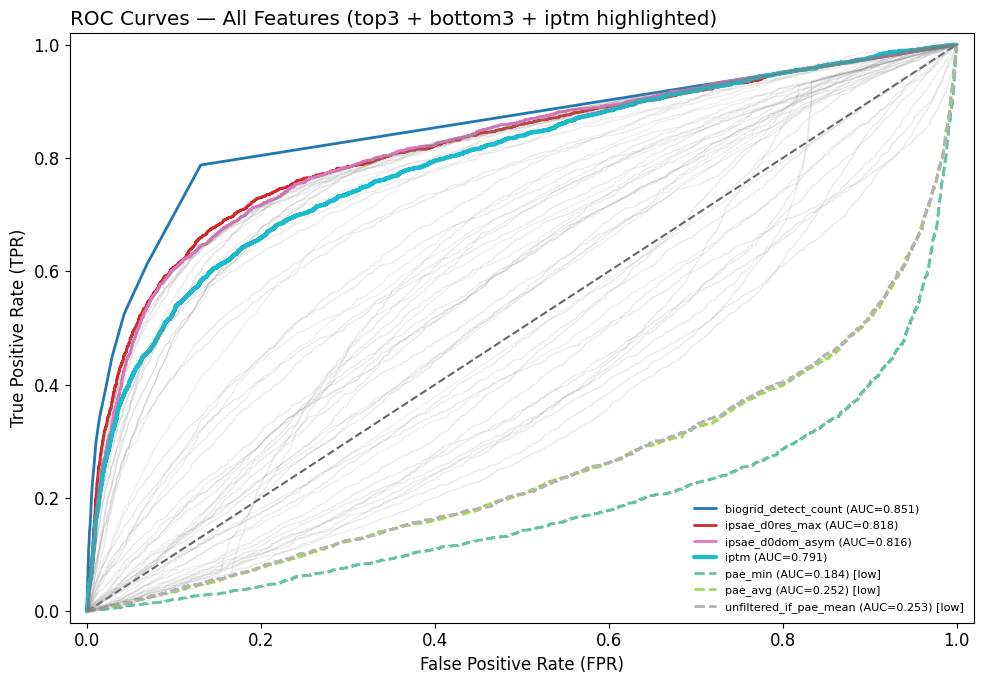

In [5]:
# ══════════════════════════════════════════════════════════
# 所有特征 ROC 曲线（同一张图）
# 高亮 AUC Top3 + Bottom3 + iptm，其余灰色细线
# ══════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc

sub = df.dropna(subset=['label']).copy()
y_true = sub['label'].values

all_features = []
for feats in FEATURE_GROUPS.values():
    all_features.extend(feats)
all_features = [f for f in all_features if f in df.columns]

roc_auc_scores, roc_data = {}, {}
for feat in all_features:
    vals = sub[feat].dropna()
    idx = vals.index
    y, x = y_true[idx], vals.values
    if feat in LOG_TRANSFORM_FEATS:
        x = np.log1p(x)
    mask = np.isfinite(x)
    if mask.sum() < 10:
        continue
    fpr, tpr, _ = roc_curve(y[mask], x[mask])
    roc_auc_scores[feat] = auc(fpr, tpr)
    roc_data[feat] = (fpr, tpr)

top3 = sorted(roc_auc_scores, key=roc_auc_scores.get, reverse=True)[:3]
bottom3 = sorted(roc_auc_scores, key=roc_auc_scores.get)[:3]
highlight_feats = list(dict.fromkeys(top3 + ['iptm'] + bottom3))

print(f'Top 3 AUC (最高):')
for f in top3:
    print(f'  {f}: {roc_auc_scores[f]:.4f}')
print(f'Bottom 3 AUC (最低):')
for f in bottom3:
    print(f'  {f}: {roc_auc_scores[f]:.4f}')
if 'iptm' not in top3 and 'iptm' not in bottom3:
    print(f'  (iptm: AUC={roc_auc_scores["iptm"]:.4f})')

plt.figure(figsize=(10, 7), facecolor='white')
# 对角线（随机分类器）
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6)

top_highlight = list(dict.fromkeys(top3 + ['iptm']))
colors_top = plt.cm.tab10(np.linspace(0, 1, len(top_highlight)))
for i, feat in enumerate(top_highlight):
    fpr, tpr = roc_data[feat]
    lw = 3.0 if feat == 'iptm' else 2.0
    plt.plot(fpr, tpr, color=colors_top[i], linewidth=lw,
             label=f'{feat} (AUC={roc_auc_scores[feat]:.3f})')

bottom_only = [f for f in bottom3 if f not in top_highlight]
if bottom_only:
    colors_bottom = plt.cm.Set2(np.linspace(0, 1, len(bottom_only)))
    for i, feat in enumerate(bottom_only):
        fpr, tpr = roc_data[feat]
        plt.plot(fpr, tpr, color=colors_bottom[i], linewidth=2.0, linestyle='--',
                 label=f'{feat} (AUC={roc_auc_scores[feat]:.3f}) [low]')

for feat in all_features:
    if feat in highlight_feats:
        continue
    fpr, tpr = roc_data[feat]
    plt.plot(fpr, tpr, color='gray', alpha=0.15, linewidth=0.8)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves — All Features (top3 + bottom3 + iptm highlighted)', loc='left')
plt.legend(fontsize=8, loc='lower right', frameon=False)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_roc_all_features.pdf', bbox_inches='tight')
# plt.savefig(f'{FIG_DIR}/fig_roc_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

=== 关键分数 ROC（test set；AUC<0.5 已反转）===
  all-feature RF       AUC: 0.9325
  structure-only RF    AUC: 0.8657
  degree-match RF      AUC: 0.5252
  ipTM                 AUC: 0.8451
  pDockQ               AUC: 0.7449
  pDockQ v2            AUC: 0.8171
  ipSAE d0res          AUC: 0.8487


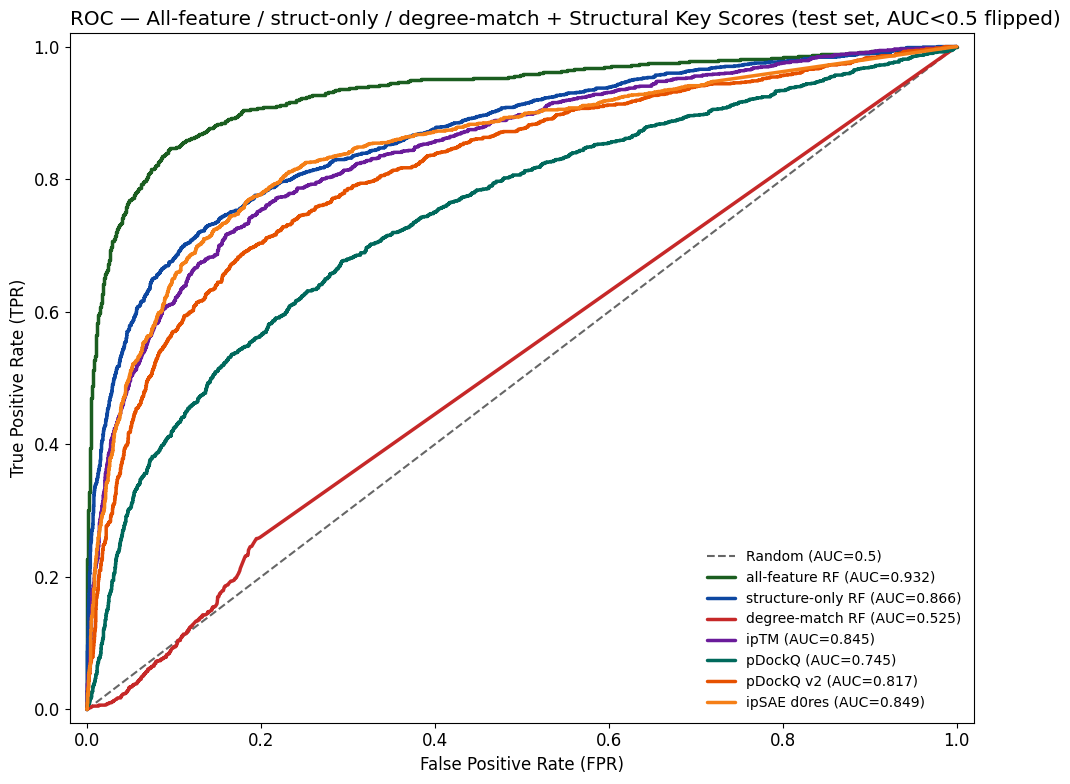

In [6]:
# ══════════════════════════════════════════════════════════
# 结构关键分数 ROC 曲线（test set；AUC<0.5 自动反转）
# 高亮：all-feature RF / structure-only RF / degree-match baseline / ipTM / pDockQ / pDockQ v2 / ipSAE(d0res)
# - 全部在 df_test 上计算（同一数据集，公平比较）
# ══════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc

if 'df_test' not in globals():
    df_test = pd.read_csv(f'{BASE}/dataset/test.tsv', sep='\t')
if 'y_prob_all' not in globals():
    import pickle
    with open(f'{BASE}/dataset/rf_all_feat_model.pkl', 'rb') as f:
        m = pickle.load(f)
    y_prob_all = m['model'].predict_proba(
        m['imputer'].transform(df_test[m['features']].values))[:, 1]
if 'y_prob_struct' not in globals():
    import pickle
    with open(f'{BASE}/dataset/rf_struct_feat_model.pkl', 'rb') as f:
        m = pickle.load(f)
    y_prob_struct = m['model'].predict_proba(
        m['imputer'].transform(df_test[m['features']].values))[:, 1]
if 'y_prob_degree' not in globals():
    y_prob_degree = load_degree_prediction(df_test)

y_test = df_test['label'].values

# ── 高亮分数（全部在 df_test 上，0~1，可比较）──
HL = {
    'all_feature_RF':    y_prob_all,                       # RF all-feature 预测概率
    'structure_only_RF': y_prob_struct,                    # RF struct-only 预测概率
    'degree_match_RF':   y_prob_degree,                    # degree-match baseline 预测概率
    'iptm':              df_test['iptm'].values,           # ipTM
    'pdockq':            df_test['pdockq_e'].values,       # pDockQ
    'pdockq2':           df_test['pdockq_e_v2'].values,    # pDockQ v2
    'ipsae_d0res':       df_test['ipsae_d0res_asym'].values,  # ipSAE d0res
}
HL_LABEL = {'all_feature_RF': 'all-feature RF', 'structure_only_RF': 'structure-only RF',
            'degree_match_RF': 'degree-match RF', 'iptm': 'ipTM',
            'pdockq': 'pDockQ', 'pdockq2': 'pDockQ v2',
            'ipsae_d0res': 'ipSAE d0res'}
HL_COLORS = {'all_feature_RF': '#1B5E20', 'structure_only_RF': '#0D47A1',
             'degree_match_RF': '#C62828', 'iptm': '#6A1B9A',
             'pdockq': '#00695C', 'pdockq2': '#E65100',
             'ipsae_d0res': '#F57F17'}

plt.figure(figsize=(10, 8), facecolor='white')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6, label='Random (AUC=0.5)')

print('=== 关键分数 ROC（test set；AUC<0.5 已反转）===')
for name, score in HL.items():
    mask = np.isfinite(score)
    y, x = y_test[mask], score[mask]
    fpr, tpr, _ = roc_curve(y, x)
    a = auc(fpr, tpr)
    flip = ''
    if a < 0.5:                       # 反方向 → 取反（-score），AUC 变为 >0.5
        x = -x
        fpr, tpr, _ = roc_curve(y, x)
        a = auc(fpr, tpr)
        flip = ' [flipped]'
    plt.plot(fpr, tpr, color=HL_COLORS[name], linewidth=2.5,
             label=f'{HL_LABEL[name]} (AUC={a:.3f}){flip}')
    print(f'  {HL_LABEL[name]:<20s} AUC: {a:.4f}{flip}')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC — All-feature / struct-only / degree-match + Structural Key Scores (test set, AUC<0.5 flipped)', loc='left')
plt.legend(frameon=False, loc='lower right', fontsize=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_roc_struct_key_scores.pdf', bbox_inches='tight')
# plt.savefig(f'{FIG_DIR}/fig_roc_struct_key_scores.png', dpi=300, bbox_inches='tight')
plt.show()

结构特征: 51 个
生物特征: 14 个

结构特征 AUC: mean=0.6343, median=0.6482, min=0.1845, max=0.8177
生物特征 AUC: mean=0.5626, median=0.6017, min=0.3876, max=0.8508


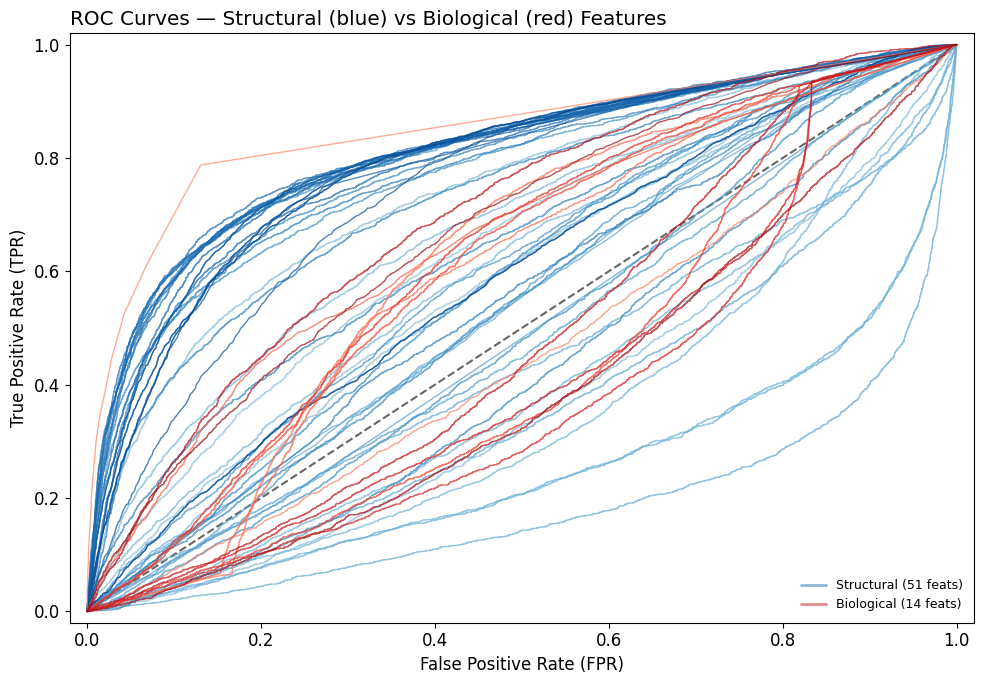

In [7]:
# ══════════════════════════════════════════════════════════
# 结构特征 vs 生物特征 ROC 曲线对比
# 蓝色系 = 结构特征，红色系 = 生物特征
# ══════════════════════════════════════════════════════════
# 定义结构/生物特征组 (ipSAE 属结构特征)
STRUCT_GROUPS = {'1_pLDDT_global', '2_pLDDT_interface', '3_PAE',
                 '4_Contact_counts', '5_Contact_scores', '6_Chemical',
                 '7_Scores_coverage', '13_ipSAE'}
BIO_GROUPS = {'8_BioGRID_Coexpr', '9_CRISPR', '10_DepMap',
              '11_T5_embedding', '12_AlphaMissense'}

struct_feats = []
bio_feats = []
for grp_name, feats in FEATURE_GROUPS.items():
    for f in feats:
        if f not in roc_auc_scores:
            continue
        if grp_name in STRUCT_GROUPS:
            struct_feats.append(f)
        elif grp_name in BIO_GROUPS:
            bio_feats.append(f)

print(f'结构特征: {len(struct_feats)} 个')
print(f'生物特征: {len(bio_feats)} 个')
print()

# 统计每组 AUC 分布
struct_aucs = [roc_auc_scores[f] for f in struct_feats]
bio_aucs = [roc_auc_scores[f] for f in bio_feats]
print(f'结构特征 AUC: mean={np.mean(struct_aucs):.4f}, median={np.median(struct_aucs):.4f}, '
      f'min={np.min(struct_aucs):.4f}, max={np.max(struct_aucs):.4f}')
print(f'生物特征 AUC: mean={np.mean(bio_aucs):.4f}, median={np.median(bio_aucs):.4f}, '
      f'min={np.min(bio_aucs):.4f}, max={np.max(bio_aucs):.4f}')

plt.figure(figsize=(10, 7), facecolor='white')
# 对角线
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6)

# 结构特征：蓝色系
n_struct = len(struct_feats)
if n_struct > 0:
    colors_struct = plt.cm.Blues(np.linspace(0.4, 0.9, n_struct))
    for i, feat in enumerate(struct_feats):
        fpr, tpr = roc_data[feat]
        plt.plot(fpr, tpr, color=colors_struct[i], alpha=0.7, linewidth=1.0,
                 label=f'{feat} ({roc_auc_scores[feat]:.3f})' if i == 0 else '')

# 生物特征：红色系
n_bio = len(bio_feats)
if n_bio > 0:
    colors_bio = plt.cm.Reds(np.linspace(0.4, 0.9, n_bio))
    for i, feat in enumerate(bio_feats):
        fpr, tpr = roc_data[feat]
        plt.plot(fpr, tpr, color=colors_bio[i], alpha=0.7, linewidth=1.0,
                 label=f'{feat} ({roc_auc_scores[feat]:.3f})' if i == 0 else '')

# 自定义图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#2171B5', linewidth=2.0, alpha=0.5, label=f'Structural ({n_struct} feats)'),
    Line2D([0], [0], color='#CB181D', linewidth=2.0, alpha=0.5, label=f'Biological ({n_bio} feats)'),
]
plt.legend(handles=legend_elements, fontsize=9, loc='lower right', frameon=False)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curves — Structural (blue) vs Biological (red) Features', loc='left')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_roc_struct_vs_bio.pdf', bbox_inches='tight')
# plt.savefig(f'{FIG_DIR}/fig_roc_struct_vs_bio.png', dpi=300, bbox_inches='tight')
plt.show()


Positive ratio (baseline AUPR): 0.3017
RF all-feat     AUPR: 0.8984
RF struct-only  AUPR: 0.7938
degree-match    AUPR: 0.3006


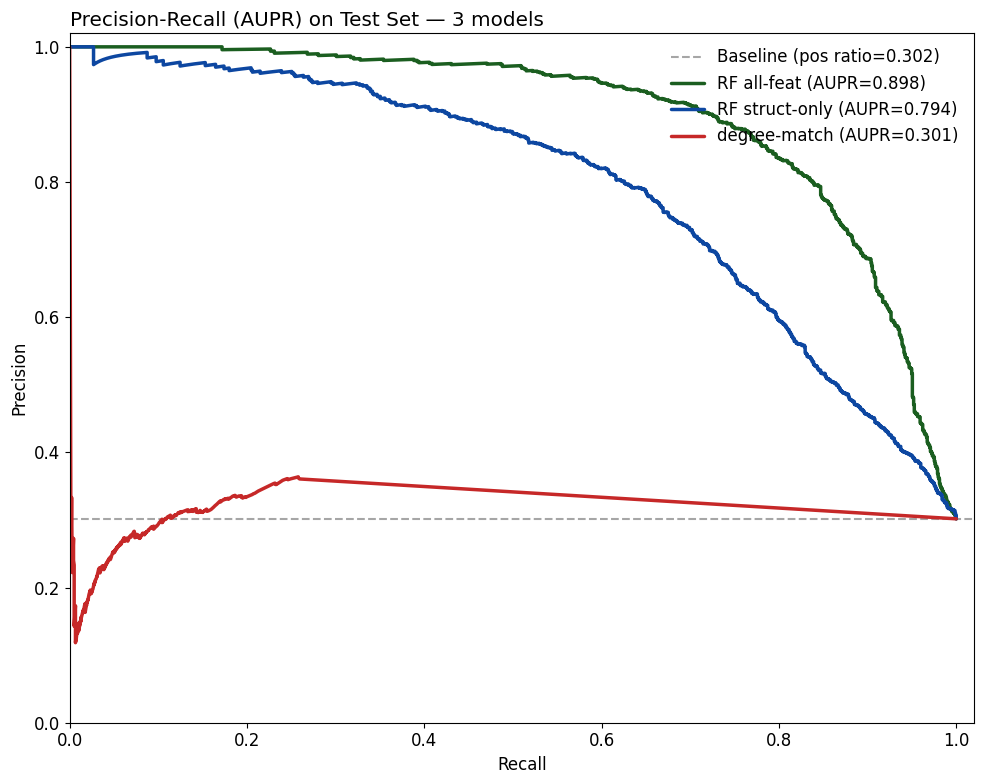

In [8]:
# ══════════════════════════════════════════════════════════
# AUPR (Precision-Recall) 曲线 — test set
# all-feature / struct-only / degree-match baseline 三条曲线
# ══════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_curve, average_precision_score

if 'y_prob_degree' not in globals():
    y_prob_degree = load_degree_prediction(df_test)


def get_pr(y_true, scores):
    """返回 (precision, recall, AUPR)，忽略非有限值。"""
    mask = np.isfinite(scores)
    p, r, _ = precision_recall_curve(y_true[mask], scores[mask])
    ap = average_precision_score(y_true[mask], scores[mask])
    return p, r, ap


prs = {
    'RF all-feat':    get_pr(y_test, y_prob_all),
    'RF struct-only': get_pr(y_test, y_prob_struct),
    'degree-match':   get_pr(y_test, y_prob_degree),
}
colors = {'RF all-feat': '#1B5E20', 'RF struct-only': '#0D47A1', 'degree-match': '#C62828'}

# 基线 = 正样本比例（随机分类器的期望 AUPR）
pos_ratio = y_test.mean()
print(f'Positive ratio (baseline AUPR): {pos_ratio:.4f}')
for name, pr in prs.items():
    print(f'{name:15s} AUPR: {pr[2]:.4f}')

plt.figure(figsize=(10, 8), facecolor='white')
plt.axhline(pos_ratio, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Baseline (pos ratio={pos_ratio:.3f})')

for name, pr in prs.items():
    plt.plot(pr[1], pr[0], color=colors[name], linewidth=2.5,
             label=f'{name} (AUPR={pr[2]:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall (AUPR) on Test Set — 3 models', loc='left')
plt.legend(frameon=False, loc='upper right')
plt.xlim([0, 1.02])
plt.ylim([0, 1.02])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig_aupr_test_3models.pdf', bbox_inches='tight')
# plt.savefig(f'{FIG_DIR}/fig_aupr_test_3models.png', dpi=300, bbox_inches='tight')
plt.show()

=== FDR=5% 时的 Recall（100 次平均曲线求交，1:1 抽样）===
正样本 n=1373，负样本全量 n=3178，每次抽样负样本 n=1373（1:1）

Feature          Threshold       FDR      Recall
all-feature RF      0.2213    0.0500      0.7314
structure RF        0.3193    0.0500      0.4470
pDockQ              0.7222    0.0500      0.0019
pDockQ v2           0.6825    0.0500      0.0532
ipTM                0.7677    0.0500      0.2826
ipSAE               0.6577    0.0500      0.2645


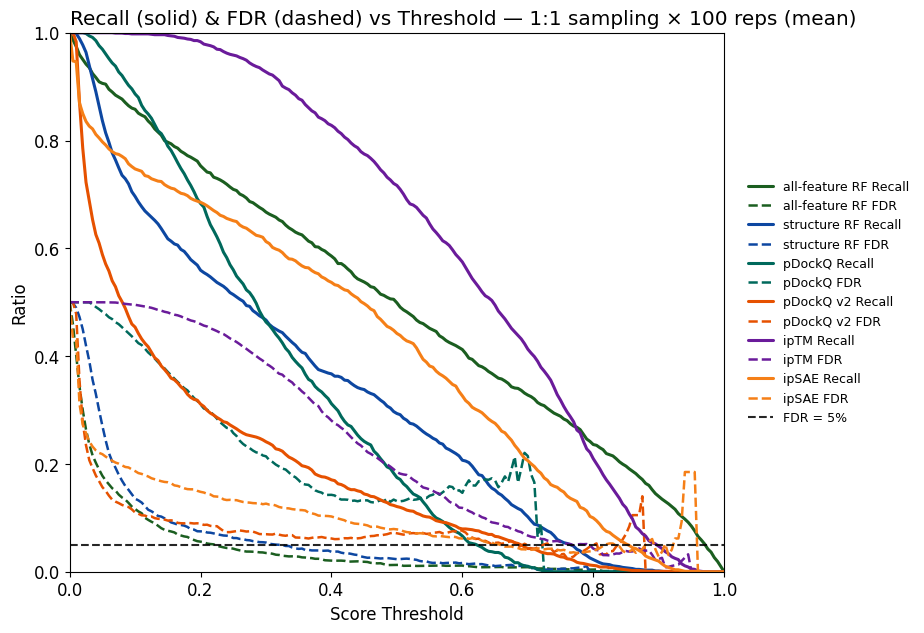

In [9]:
# ══════════════════════════════════════════════════════════
# 多特征打分：FDR=5% 时的 Recall（线性插值）+ 阈值曲线
# - 1:1 正负 label 抽样（正样本全抽，负样本抽至等量），重复 10 次取平均
# - 特征：all-feature RF / structure RF / degree-match RF / pdockq / pdockq2 / iptm / ipsae
# - 曲线：x=阈值, y=比例；实线=Recall, 虚线=FDR，另画 FDR=5% 参考虚线
# ══════════════════════════════════════════════════════════
import warnings
import numpy as np
import matplotlib.pyplot as plt



# ── 特征分数（与 df_test 行对齐）──
SCORES = {
    'all_feature_RF':  y_prob_all,                        # RF all-feature 预测概率
    'structure_RF':    y_prob_struct,                     # RF struct-only 预测概率
    'pdockq':          df_test['pdockq_e'].values,        # pDockQ
    'pdockq2':         df_test['pdockq_e_v2'].values,     # pDockQ v2
    'iptm':            df_test['iptm'].values,
    'ipsae':           df_test['ipsae_d0res_asym'].values,  # ipSAE（逐残基 d0，非对称）
}
LABEL_NAME = {'all_feature_RF': 'all-feature RF', 'structure_RF': 'structure RF',
              'degree_match_RF': 'degree-match RF', 'pdockq': 'pDockQ',
              'pdockq2': 'pDockQ v2', 'iptm': 'ipTM', 'ipsae': 'ipSAE'}
COLORS = {'all_feature_RF': '#1B5E20', 'structure_RF': '#0D47A1',
          'degree_match_RF': '#C62828', 'pdockq': '#00695C',
          'pdockq2': '#E65100', 'iptm': '#6A1B9A', 'ipsae': '#F57F17'}
y_true = df_test['label'].values

FDR_TARGET = 0.05
N_REP = 100
rng = np.random.default_rng(42)


def interpolate_first_crossing(grid, rec, fdr, fdr_target=FDR_TARGET):
    """阈值升序扫描（低→高阈值），取 FDR 首次穿越 fdr_target 的第一个交点，
    在该处对 (阈值→Recall) 线性插值，返回 (阈值, Recall)。
    说明：FDR 随阈值不单调，可能多次穿越目标线；取升序扫描遇到的第一个
    交点，结果唯一稳定，不会随交叉点震荡。"""
    t = np.asarray(grid, dtype=float)          # 阈值升序（0→1）
    r = np.asarray(rec, dtype=float)
    f = np.asarray(fdr, dtype=float)
    mask = np.isfinite(f) & np.isfinite(r)
    t, r, f = t[mask], r[mask], f[mask]
    if len(f) < 2:
        return np.nan, np.nan
    for i in range(len(f) - 1):
        if (f[i] - fdr_target) * (f[i + 1] - fdr_target) <= 0:   # 穿越目标线
            w = (fdr_target - f[i]) / (f[i + 1] - f[i])
            return float(t[i] + w * (t[i + 1] - t[i])), float(r[i] + w * (r[i + 1] - r[i]))
    # 全程未穿越：FDR 全高于目标 → 取 FDR 最小点；全低于 → 取 FDR 最大点
    if f[0] > fdr_target:
        j = int(np.argmin(f))
    else:
        j = int(np.argmax(f))
    return float(t[j]), float(r[j])


def recall_fdr_curve(score, y, grid):
    """在给定阈值网格上计算 (recall, fdr) 曲线。"""
    s = np.asarray(score, dtype=float)
    yy = np.asarray(y, dtype=int)
    mask = np.isfinite(s)
    s, yy = s[mask], yy[mask]
    rec = np.zeros(len(grid))
    fdr = np.full(len(grid), np.nan)
    for i, t in enumerate(grid):
        pred = (s >= t).astype(int)
        tp = int(((pred == 1) & (yy == 1)).sum())
        fp = int(((pred == 1) & (yy == 0)).sum())
        fn = int(((pred == 0) & (yy == 1)).sum())
        rec[i] = tp / (tp + fn) if tp + fn > 0 else 0.0
        fdr[i] = fp / (tp + fp) if tp + fp > 0 else np.nan
    return rec, fdr


# ── 10 次 1:1 抽样重复 ──
pos_idx = np.where(y_true == 1)[0]
neg_idx = np.where(y_true == 0)[0]
n_pos = len(pos_idx)

grid = np.linspace(0, 1, 201)    # 公共阈值网格（所有指标分数均在 0~1）

records = {k: [] for k in SCORES}                       # 每次 FDR5% 的 (thr, fdr, recall)
curves = {k: {'rec': [], 'fdr': []} for k in SCORES}    # 每次的整条曲线

for rep in range(N_REP):
    neg_sampled = rng.choice(neg_idx, size=n_pos, replace=False)
    idx = np.concatenate([pos_idx, neg_sampled])
    for k, score in SCORES.items():
        r, f = recall_fdr_curve(score[idx], y_true[idx], grid)
        curves[k]['rec'].append(r)
        curves[k]['fdr'].append(f)

# ── 平均曲线后求 FDR=5% 交点（FDR 与 Recall 均用 N_REP 次平均曲线）──
for k in SCORES:
    rec_avg = np.mean(curves[k]['rec'], axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)   # 阈值过高时 FDR 无定义（全 NaN）
        fdr_avg = np.nanmean(np.vstack(curves[k]['fdr']), axis=0)
    thr5, rec5 = interpolate_first_crossing(grid, rec_avg, fdr_avg, FDR_TARGET)
    records[k].append((thr5, FDR_TARGET, rec5))
    curves[k]['rec_avg'] = rec_avg
    curves[k]['fdr_avg'] = fdr_avg

# ── 表：FDR=5% 时的 Recall（10 次平均）──
print(f'=== FDR={FDR_TARGET:.0%} 时的 Recall（{N_REP} 次平均曲线求交，1:1 抽样）===')
print(f'正样本 n={n_pos}，负样本全量 n={len(neg_idx)}，每次抽样负样本 n={n_pos}（1:1）\n')
print(f'{"Feature":<16}{"Threshold":>10}{"FDR":>10}{"Recall":>12}')
rows = []
for k in SCORES:
    thr5, fdr5, rec5 = records[k][0]
    rows.append((LABEL_NAME[k], thr5, fdr5, rec5))
    print(f'{LABEL_NAME[k]:<16}{thr5:>10.4f}{fdr5:>10.4f}{rec5:>12.4f}')

# ── 曲线图：x=阈值, y=比例；实线=Recall, 虚线=FDR ──
fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
for k in SCORES:
    rec_avg = curves[k]['rec_avg']
    fdr_avg = curves[k]['fdr_avg']
    ax.plot(grid, rec_avg, color=COLORS[k], linestyle='-', linewidth=2.2,
            label=f'{LABEL_NAME[k]} Recall')
    ax.plot(grid, fdr_avg, color=COLORS[k], linestyle='--', linewidth=1.8,
            label=f'{LABEL_NAME[k]} FDR')

ax.axhline(FDR_TARGET, color='black', linestyle='--', linewidth=1.5, alpha=0.85,
           label=f'FDR = {FDR_TARGET:.0%}')
ax.set_xlabel('Score Threshold')
ax.set_ylabel('Ratio')
ax.set_title(f'Recall (solid) & FDR (dashed) vs Threshold — 1:1 sampling × {N_REP} reps (mean)', loc='left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
plt.subplots_adjust(right=0.72)
fig.savefig(f'{FIG_DIR}/fig_fdr5_recall_threshold.pdf', bbox_inches='tight')
# fig.savefig(f'{FIG_DIR}/fig_fdr5_recall_threshold.png', dpi=300, bbox_inches='tight')
plt.show()





In [10]:
df_test["all_feature_RF"] = y_prob_all
df_test["structure_RF"] = y_prob_struct
df_test

,pair_id,dimer_id,uniprot_A,uniprot_B,label,source,dom_A_start,dom_A_end,dom_B_start,dom_B_end,...,depmap_cosine_dist,depmap_euclidian_dist,t5_domain_embedding_cosine_dist,t5_domain_embedding_euclidian_dist,avg_af_missense_score_diff,af_missense_score_mean,af_missense_score_mean_diff,num_significant_afm_scores,all_feature_RF,structure_RF
0,Q8IV36_Q9C0F1,Q8IV36_1_324__Q9C0F1_1_178,Q8IV36,Q9C0F1,0,random,1,324,1,178,...,0.669071,9.009968,0.665000,1.318369,0.079823,0.644674,0.315446,465,0.008714,0.023467
1,Q15466_Q16549,Q15466_1_257__Q16549_138_418,Q15466,Q16549,0,random,1,257,138,418,...,0.809746,9.362351,0.527977,1.298559,0.370401,0.538051,0.408481,11,0.002305,0.043381
2,P78316_Q96LL3,P78316_397_651__Q96LL3_1_132,P78316,Q96LL3,0,random,397,651,1,132,...,NaN,NaN,0.822394,1.902871,0.004963,0.479393,0.259447,61,0.004833,0.030689
3,A2RRH5_P42229,A2RRH5_482_827__P42229_1_127,A2RRH5,P42229,0,random,482,827,1,127,...,0.508957,9.852757,0.521667,1.057179,0.107851,0.559966,0.387426,47,0.011627,0.025683
4,Q96L58_Q9UBC1,Q96L58_1_329__Q9UBC1_288_381,Q96L58,Q9UBC1,0,random,1,329,288,381,...,1.077928,8.866776,0.436380,1.449005,0.014602,0.420999,0.285563,9,0.019878,0.072008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4546,P00846_P05496,P00846_1_226__P05496_1_136,P00846,P05496,1,PDB_contact,1,226,1,136,...,NaN,NaN,0.590414,1.944759,0.041570,0.852882,0.167075,438,0.010164,0.023905
4547,Q16595_Q9Y697,Q16595_1_210__Q9Y697_1_350,Q16595,Q9Y697,1,PDB_contact,1,210,1,350,...,0.132423,38.989120,0.479082,1.335099,0.155352,0.655640,0.388502,128,0.015951,0.027113
4548,P46777_Q9H6F5,P46777_1_297__Q9H6F5_32_360,P46777,Q9H6F5,1,PDB_contact,1,297,32,360,...,0.054963,54.587486,0.808828,2.272060,0.472909,0.739868,0.415083,475,0.133056,0.330690
4549,P28331_P56556,P28331_530_727__P56556_1_128,P28331,P56556,1,PDB_contact,530,727,1,128,...,0.081265,8.506526,0.615212,1.374610,0.040322,0.680868,0.271203,37,0.099302,0.047825


全量 test: 正 1373 / 负 3178（pos:neg = 1:2.31）

════════ 分数 [all-feature RF] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.2213      0.7314
1:4          794    3178    0.4828      0.5108
1:16         199    3178    0.8078      0.2355
1:64          50    3178    0.8728      0.1643
1:128         25    3178    0.8738      0.1725


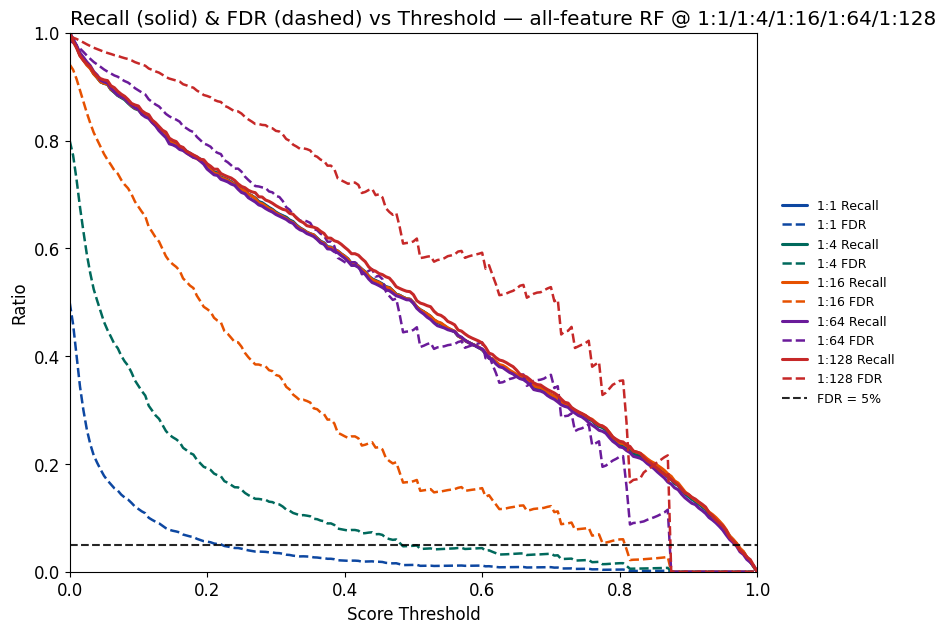


════════ 分数 [structure RF] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.3193      0.4470
1:4          794    3178    0.6344      0.1708
1:16         199    3178    0.7935      0.0277
1:64          50    3178    0.7945      0.0279
1:128         25    3178    0.7946      0.0245


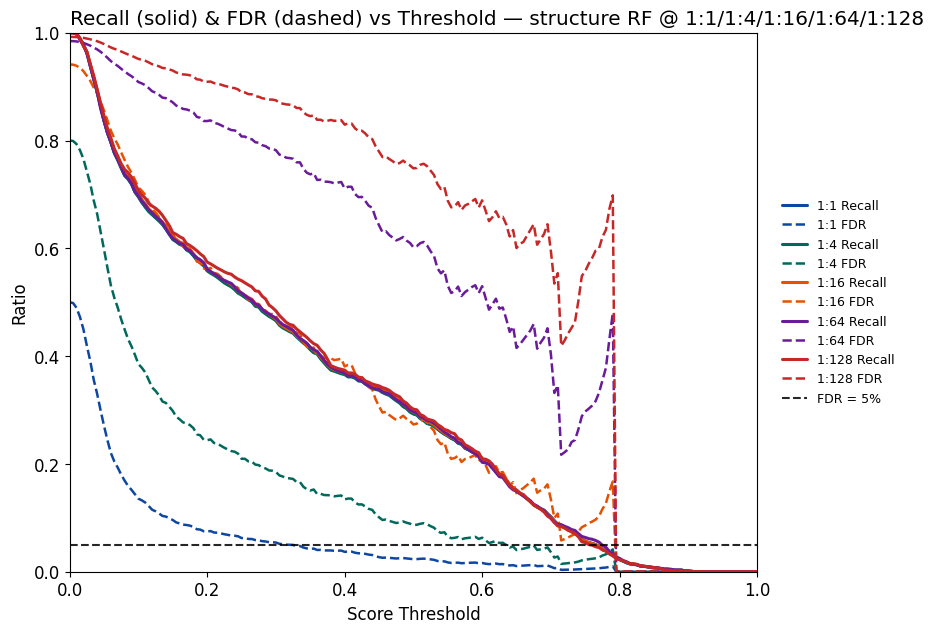


════════ 分数 [pDockQ] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.7222      0.0019
1:4          794    3178    0.7242      0.0011
1:16         199    3178    0.7247      0.0009
1:64          50    3178    0.7247      0.0011
1:128         25    3178    0.7247      0.0013


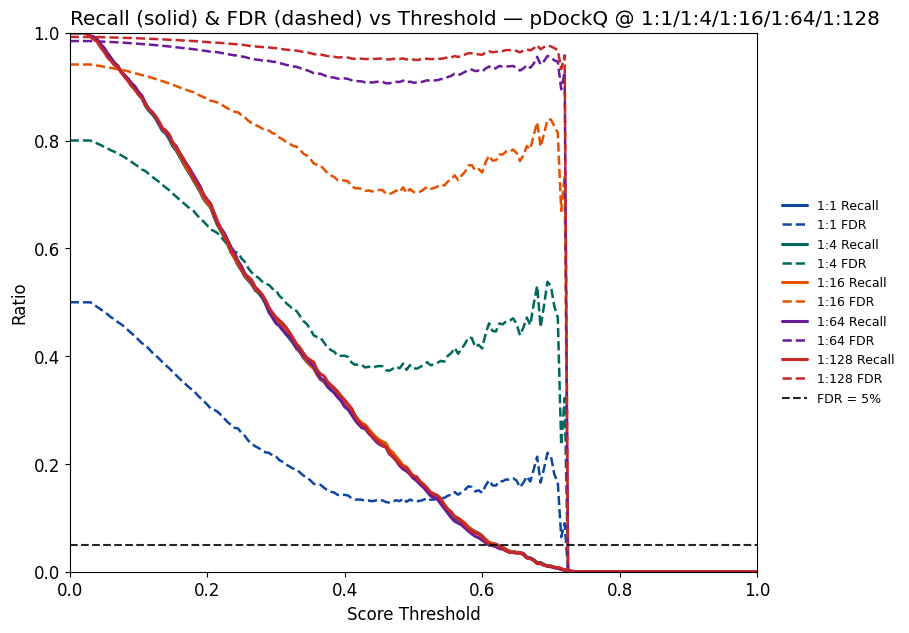


════════ 分数 [pDockQ v2] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.6825      0.0532
1:4          794    3178    0.8796      0.0014
1:16         199    3178    0.8797      0.0018
1:64          50    3178    0.8797      0.0022
1:128         25    3178    0.8797      0.0004


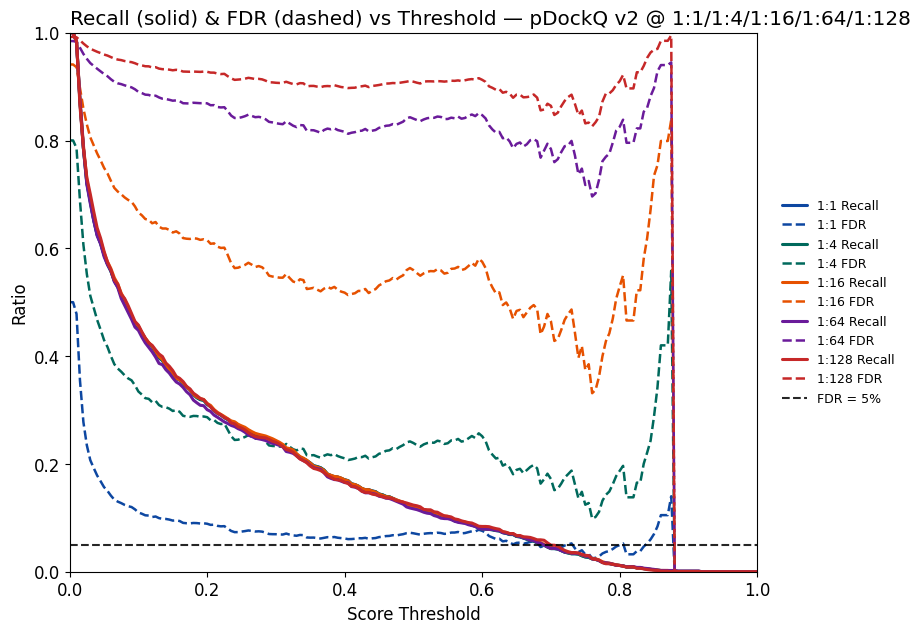


════════ 分数 [ipTM] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.7677      0.2826
1:4          794    3178    0.9089      0.0382
1:16         199    3178    0.9495      0.0056
1:64          50    3178    0.9497      0.0046
1:128         25    3178    0.9497      0.0058


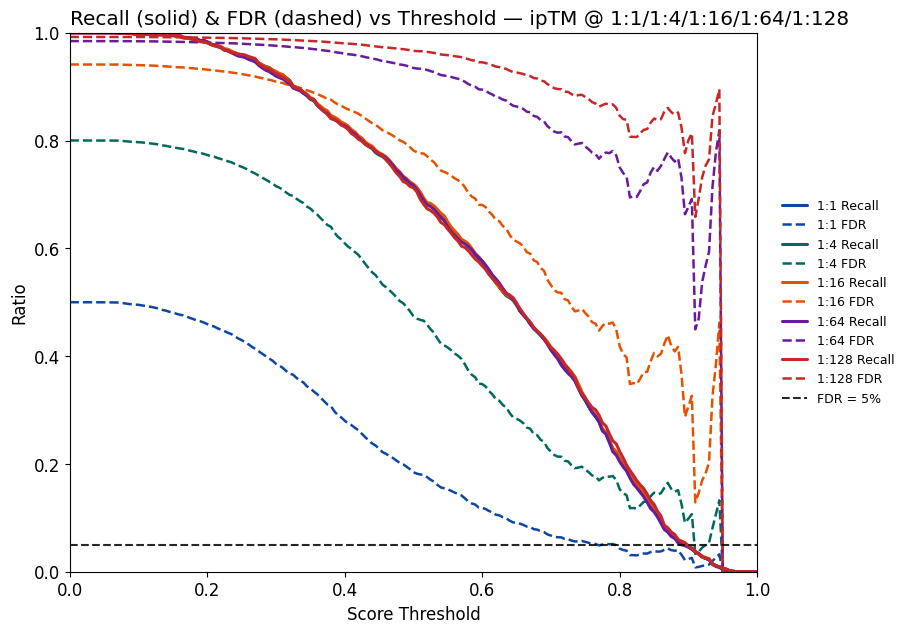


════════ 分数 [ipSAE] ════════
  ratio   n_pos   n_neg    thr@5%   recall@5%
1:1         1373    1373    0.6577      0.2645
1:4          794    3178    0.9596      0.0008
1:16         199    3178    0.9597      0.0007
1:64          50    3178    0.9597      0.0010
1:128         25    3178    0.9597      0.0008


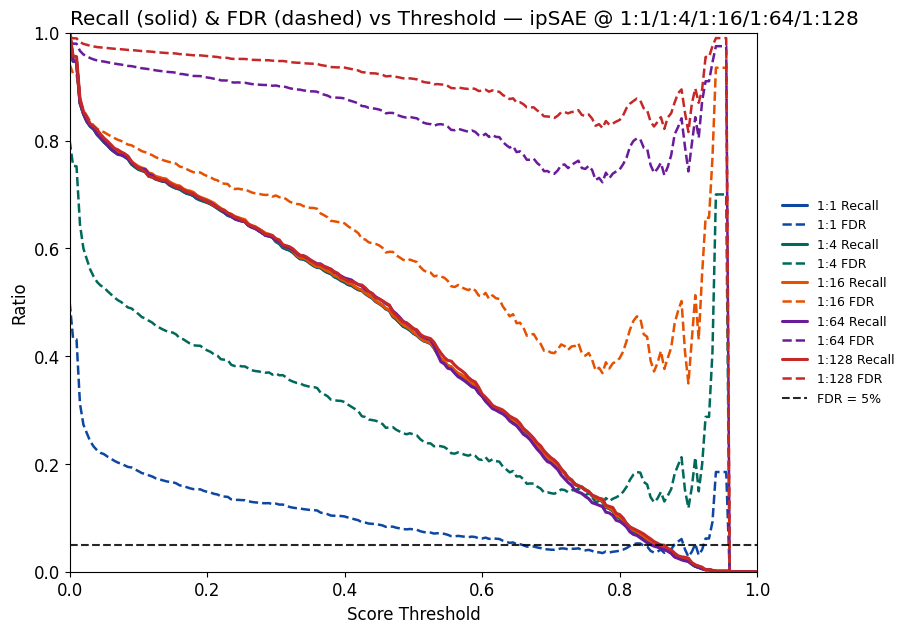

In [11]:
# ══════════════════════════════════════════════════════════
# 多分数 × 多比例子集：Recall/FDR vs 阈值曲线（循环，FDR=5% 处线性插值）
# - 对 SCORE_KEYS 里每个分数：画该分数在 1:1/1:4/1:16/1:64/1:128
#   子集下的 Recall(实线)/FDR(虚线) vs 阈值曲线，并统计 FDR=5% 时 Recall
# - 子集构建：n_pos=min(全量正, 全量负/k); n_neg=min(全量负, 全量正*k)
#   * 1:1 → 正全取、负抽样至等量；1:4~1:128 → 负全取、正按比例抽样
# - 每个比例重复抽样 N_REP 次；所有分数共用同一批抽样子集（公平比较）
# ══════════════════════════════════════════════════════════
import warnings
import numpy as np
import matplotlib.pyplot as plt

if 'y_prob_degree' not in globals():
    y_prob_degree = load_degree_prediction(df_test)

# ==================== 接口：改这里指定画哪些分数 ====================
SCORE_KEYS = ['all_feature_RF', 'structure_RF',
              'pdockq', 'pdockq2', 'iptm', 'ipsae']
# =====================================================================

SCORES = {
    'all_feature_RF':  y_prob_all,                        # RF all-feature 预测概率
    'structure_RF':    y_prob_struct,                     # RF struct-only 预测概率
    'pdockq':          df_test['pdockq_e'].values,        # pDockQ
    'pdockq2':         df_test['pdockq_e_v2'].values,     # pDockQ v2
    'iptm':            df_test['iptm'].values,
    'ipsae':           df_test['ipsae_d0res_asym'].values,  # ipSAE（逐残基 d0）
}
LABEL_NAME = {'all_feature_RF': 'all-feature RF', 'structure_RF': 'structure RF',
              'degree_match_RF': 'degree-match RF', 'pdockq': 'pDockQ',
              'pdockq2': 'pDockQ v2', 'iptm': 'ipTM', 'ipsae': 'ipSAE'}
y_all = df_test['label'].values

FDR_TARGET = 0.05
RATIOS = [1, 4, 16, 64, 128]            # 目标 pos:neg = 1:k
N_REP = 100
rng = np.random.default_rng(42)

pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]
n_pos_all = len(pos_idx)
n_neg_all = len(neg_idx)
print(f'全量 test: 正 {n_pos_all} / 负 {n_neg_all}（pos:neg = 1:{n_neg_all/n_pos_all:.2f}）')


def recall_fdr_curve(s, y, grid):
    """在给定阈值网格上计算 (recall, fdr) 曲线。"""
    rec = np.zeros(len(grid))
    fdr = np.full(len(grid), np.nan)
    for i, t in enumerate(grid):
        pred = (s >= t).astype(int)
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        rec[i] = tp / (tp + fn) if tp + fn > 0 else 0.0
        fdr[i] = fp / (tp + fp) if tp + fp > 0 else np.nan
    return rec, fdr


def interpolate_first_crossing(grid, rec, fdr, fdr_target=FDR_TARGET):
    """阈值升序扫描（低→高阈值），取 FDR 首次穿越 fdr_target 的第一个交点，
    在该处对 (阈值→Recall) 线性插值，返回 (阈值, Recall)。
    说明：FDR 随阈值不单调，可能多次穿越目标线；取升序扫描遇到的第一个
    交点，结果唯一稳定，不会随交叉点震荡。"""
    t = np.asarray(grid, dtype=float)          # 阈值升序（0→1）
    r = np.asarray(rec, dtype=float)
    f = np.asarray(fdr, dtype=float)
    mask = np.isfinite(f) & np.isfinite(r)
    t, r, f = t[mask], r[mask], f[mask]
    if len(f) < 2:
        return np.nan, np.nan
    for i in range(len(f) - 1):
        if (f[i] - fdr_target) * (f[i + 1] - fdr_target) <= 0:   # 穿越目标线
            w = (fdr_target - f[i]) / (f[i + 1] - f[i])
            return float(t[i] + w * (t[i + 1] - t[i])), float(r[i] + w * (r[i + 1] - r[i]))
    # 全程未穿越：FDR 全高于目标 → 取 FDR 最小点；全低于 → 取 FDR 最大点
    if f[0] > fdr_target:
        j = int(np.argmin(f))
    else:
        j = int(np.argmax(f))
    return float(t[j]), float(r[j])


grid = np.linspace(0, 1, 201)
RATIO_COLORS = {1: '#0D47A1', 4: '#00695C', 16: '#E65100', 64: '#6A1B9A', 128: '#C62828'}

# ── 预先为每个比例生成 N_REP 套子集索引（所有分数共用，保证公平）──
subsets = {}
for k in RATIOS:
    n_pos = int(round(min(n_pos_all, n_neg_all / k)))
    n_neg = int(round(min(n_neg_all, n_pos_all * k)))
    idxs = []
    for _ in range(N_REP):
        pi = pos_idx if n_pos == n_pos_all else rng.choice(pos_idx, size=n_pos, replace=False)
        ni = neg_idx if n_neg == n_neg_all else rng.choice(neg_idx, size=n_neg, replace=False)
        idxs.append(np.concatenate([pi, ni]))
    subsets[k] = (n_pos, n_neg, idxs)

# ── 循环每个分数：表格 + 图 ──
for key in SCORE_KEYS:
    score = SCORES[key]
    print(f'\n════════ 分数 [{LABEL_NAME[key]}] ════════')
    print(f'{"ratio":>7}{"n_pos":>8}{"n_neg":>8}{"thr@5%":>10}{"recall@5%":>12}')
    curves = {}
    for k in RATIOS:
        n_pos, n_neg, idxs = subsets[k]
        rec_reps, fdr_reps = [], []
        for idx in idxs:
            rec, fdr = recall_fdr_curve(score[idx], y_all[idx], grid)
            rec_reps.append(rec)
            fdr_reps.append(fdr)
        rec_avg = np.mean(rec_reps, axis=0)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)   # 阈值过高时 FDR 无定义（全 NaN）
            fdr_avg = np.nanmean(np.vstack(fdr_reps), axis=0)
        thr5, rec5 = interpolate_first_crossing(grid, rec_avg, fdr_avg, FDR_TARGET)
        curves[k] = (rec_avg, fdr_avg)
        print(f'1:{k:<6d}{n_pos:>8d}{n_neg:>8d}{thr5:>10.4f}{rec5:>12.4f}')

    # 图：该分数在不同比例子集下的 Recall/FDR vs 阈值
    fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
    for k in RATIOS:
        rec_avg, fdr_avg = curves[k]
        ax.plot(grid, rec_avg, color=RATIO_COLORS[k], linestyle='-', linewidth=2.2,
                label=f'1:{k} Recall')
        ax.plot(grid, fdr_avg, color=RATIO_COLORS[k], linestyle='--', linewidth=1.8,
                label=f'1:{k} FDR')
    ax.axhline(FDR_TARGET, color='black', linestyle='--', linewidth=1.5, alpha=0.85,
               label=f'FDR = {FDR_TARGET:.0%}')
    ax.set_xlabel('Score Threshold')
    ax.set_ylabel('Ratio')
    ax.set_title(f'Recall (solid) & FDR (dashed) vs Threshold — {LABEL_NAME[key]} @ 1:1/1:4/1:16/1:64/1:128', loc='left')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
    plt.subplots_adjust(right=0.75)
    fig.savefig(f'{FIG_DIR}/fig_fdr5_recall_ratio_{key}.pdf', bbox_inches='tight')
    # fig.savefig(f'{FIG_DIR}/fig_fdr5_recall_ratio_{key}.png', dpi=300, bbox_inches='tight')
    plt.show()

1:128 子集（复用多比例 cell）：n_pos=25, n_neg=3178
  all-feature RF     FDR=5%: thr=0.8738, recall=0.1725 ± 0.0772 (n=100)
  all-feature RF     FDR=10%: thr=0.8727, recall=0.1738 ± 0.0982 (n=100)
  structure RF       FDR=5%: thr=0.7946, recall=0.0245 ± 0.0542 (n=100)
  structure RF       FDR=10%: thr=0.7943, recall=0.0249 ± 0.0540 (n=100)
  ipSAE              FDR=5%: thr=0.9597, recall=0.0008 ± 0.1029 (n=100)
  ipSAE              FDR=10%: thr=0.9595, recall=0.0008 ± 0.1029 (n=100)
  ipTM               FDR=5%: thr=0.9497, recall=0.0058 ± 0.0916 (n=100)
  ipTM               FDR=10%: thr=0.9494, recall=0.0060 ± 0.0915 (n=100)


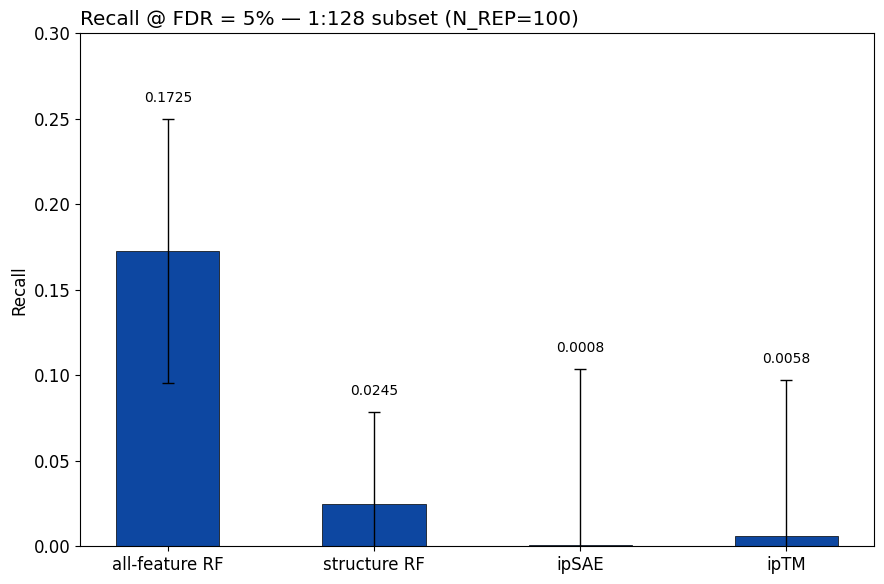

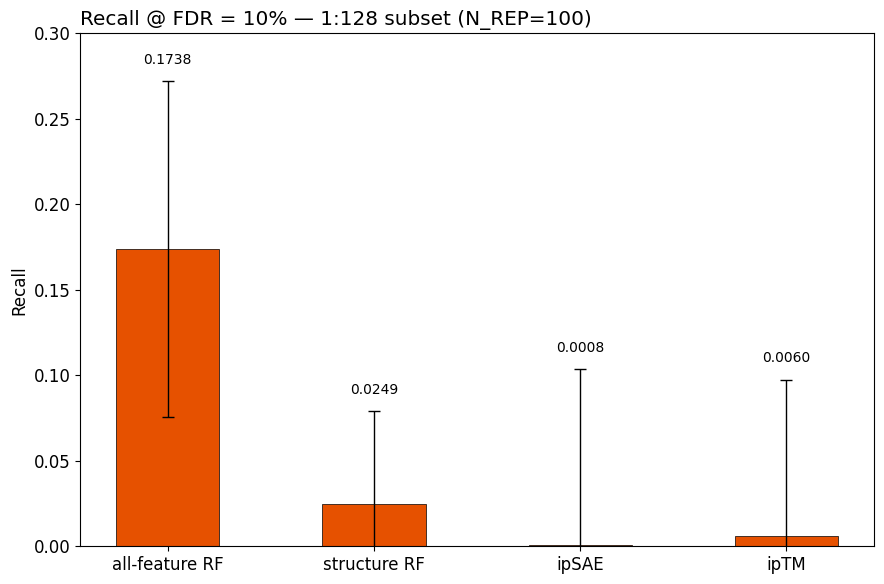


=== 1:128 子集 · FDR=10% 阈值 ===
  all-feature RF     thr@10% = 0.8727
  structure RF       thr@10% = 0.7943
  ipSAE              thr@10% = 0.9595
  ipTM               thr@10% = 0.9494


In [24]:
# ══════════════════════════════════════════════════════════
# 柱状图：1:128 子集下各分数在 FDR=5% 与 FDR=10% 时的 Recall（两张图，带 error bar）
# 复用「多比例 cell」生成的 subsets[128] 同一套子集（数值与多比例表严格一致）
# error bar = N_REP 次重复各自求 FDR 交点得到的 Recall 的 std
# ══════════════════════════════════════════════════════════
assert 'subsets' in globals(), '请先运行上方「多分数 × 多比例子集」cell 生成 subsets'

RATIO_K = 128
n_pos_128, n_neg_128, idxs_128 = subsets[RATIO_K]
print(f'1:{RATIO_K} 子集（复用多比例 cell）：n_pos={n_pos_128}, n_neg={n_neg_128}')

BAR_KEYS = ['all_feature_RF', 'structure_RF', 'ipsae', 'iptm']
BAR_FDRS = [0.05, 0.10]

# ── 计算各分数在 FDR=5%/10% 的 (阈值, recall) ──
rec_at_fdr = {k: {} for k in BAR_KEYS}    # {k: {fdr: recall 主值（平均曲线交点）}}
rec_std_fdr = {k: {} for k in BAR_KEYS}   # {k: {fdr: recall 标准差（per-rep error bar）}}
thr_at_fdr = {k: {} for k in BAR_KEYS}    # {k: {fdr: threshold}}
for k in BAR_KEYS:
    rec_reps, fdr_reps = [], []
    for idx in idxs_128:
        r, f = recall_fdr_curve(SCORES[k][idx], y_all[idx], grid)
        rec_reps.append(r)
        fdr_reps.append(f)
    rec_avg = np.mean(rec_reps, axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)   # 阈值过高时 FDR 无定义（全 NaN）
        fdr_avg = np.nanmean(np.vstack(fdr_reps), axis=0)
    for fdr in BAR_FDRS:
        thr, rc = interpolate_first_crossing(grid, rec_avg, fdr_avg, fdr)   # 平均曲线交点（主值）
        # 每次重复单独求 FDR 交点 → recall 分布（error bar 用 std）
        rec_each = []
        for idx in idxs_128:
            r, f = recall_fdr_curve(SCORES[k][idx], y_all[idx], grid)
            _, rc_i = interpolate_first_crossing(grid, r, f, fdr)
            if np.isfinite(rc_i):
                rec_each.append(rc_i)
        rec_each = np.asarray(rec_each)
        rec_at_fdr[k][fdr] = rc
        rec_std_fdr[k][fdr] = float(rec_each.std()) if len(rec_each) > 1 else 0.0
        thr_at_fdr[k][fdr] = thr
        print(f'  {LABEL_NAME[k]:<18s} FDR={fdr:.0%}: thr={thr:.4f}, '
              f'recall={rc:.4f} ± {rec_std_fdr[k][fdr]:.4f} (n={len(rec_each)})')

# ── 每个 FDR 各画一张柱状图（带 error bar）──
bar_names = [LABEL_NAME[k] for k in BAR_KEYS]
x = np.arange(len(bar_names))
colors_bar = {0.05: '#0D47A1', 0.10: '#E65100'}

for fdr in BAR_FDRS:
    vals = [rec_at_fdr[k][fdr] for k in BAR_KEYS]
    errs = [rec_std_fdr[k][fdr] for k in BAR_KEYS]
    fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
    ax.bar(x, vals, 0.5, color=colors_bar[fdr], edgecolor='black', linewidth=0.5,
           yerr=errs, capsize=4, error_kw={'elinewidth': 1.0, 'ecolor': 'black'})
    for xi, v, e in zip(x, vals, errs):
        ax.text(xi, v + e + 0.01, f'{v:.4f}', ha='center', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_names)
    ax.set_ylabel('Recall')
    ax.set_ylim(0, 0.3)
    ax.set_title(f'Recall @ FDR = {fdr:.0%} — 1:{RATIO_K} subset (N_REP={len(idxs_128)})', loc='left')
    plt.tight_layout()
    fig.savefig(f'{FIG_DIR}/fig_recall_fdr{int(fdr*100)}_bars_1to{RATIO_K}.pdf', bbox_inches='tight')
    # fig.savefig(f'{FIG_DIR}/fig_recall_fdr{int(fdr*100)}_bars_1to{RATIO_K}.png', dpi=300, bbox_inches='tight')
    plt.show()

print('\n=== 1:128 子集 · FDR=10% 阈值 ===')
for k in BAR_KEYS:
    print(f'  {LABEL_NAME[k]:<18s} thr@10% = {thr_at_fdr[k][0.10]:.4f}')

1:128 子集：n_pos=25, n_neg=3178（100 套抽样）
诊断 → 全量 test 正样本 n_pos_all=1373，负样本 n_neg_all=3178
  固定阈值 all-feature RF     = 0.8738
  固定阈值 structure RF       = 0.7946
  固定阈值 ipSAE              = 0.9597
  固定阈值 ipTM               = 0.9497
  all-feature RF    : recall = 0.1716 ± 0.0772 (median 0.1600); 实际 FDR = 0.2225
  structure RF      : recall = 0.0240 ± 0.0294 (median 0.0000); 实际 FDR = 0.0000
  ipSAE             : recall = 0.0008 ± 0.0056 (median 0.0000); 实际 FDR = 0.0000
  ipTM              : recall = 0.0064 ± 0.0157 (median 0.0000); 实际 FDR = 0.0000


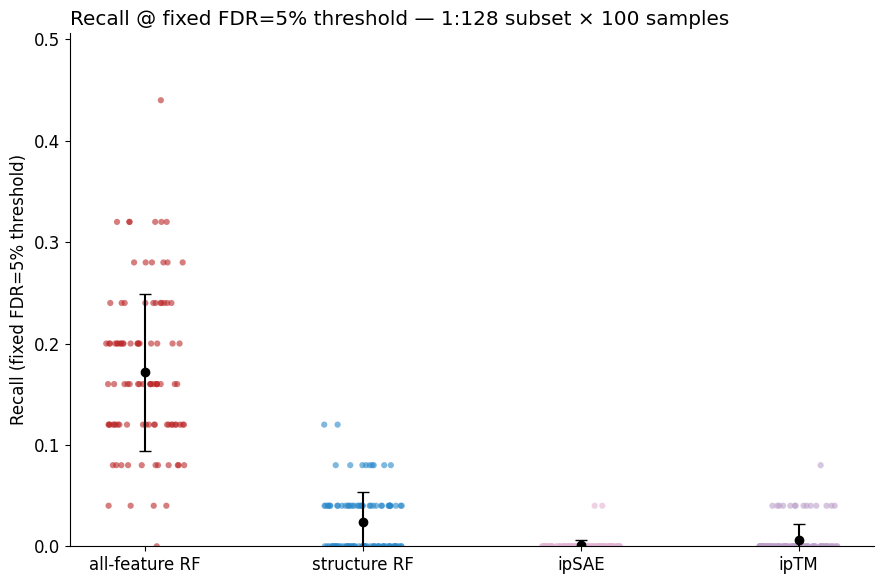

In [29]:
# ══════════════════════════════════════════════════════════
# 固定阈值法：1:128 子集 FDR=5% 阈值固定 → 抽 100 次 → 每次算 recall → 散点图
# - 阈值 = 平均曲线交点 FDR=5% 阈值（每分数唯一，与多比例表一致）
# - 100 次抽样复用 subsets[128]（与前面所有分析同一批子集，公平比较）
# - 每次用固定阈值判定 recall = TP/(TP+FN)，画 jitter 散点 + mean±std
# ══════════════════════════════════════════════════════════
assert 'subsets' in globals(), '请先运行上方「多分数 × 多比例子集」cell 生成 subsets'

RATIO_K = 128
n_pos_128, n_neg_128, idxs_128 = subsets[RATIO_K]
FDR_TARGET = 0.05
print(f'1:{RATIO_K} 子集：n_pos={n_pos_128}, n_neg={n_neg_128}（{len(idxs_128)} 套抽样）')

pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]
print(f'诊断 → 全量 test 正样本 n_pos_all={len(pos_idx)}，负样本 n_neg_all={len(neg_idx)}')
if n_pos_128 == len(pos_idx) and n_neg_128 == len(neg_idx):
    print('⚠ 注意：n_pos/n_neg 已等于全量，100 次抽样完全相同 → 散点将无波动（此思路无意义）')

BAR_KEYS = ['all_feature_RF', 'structure_RF', 'ipsae', 'iptm']

# ── 1) 每个分数的固定阈值 = 平均曲线交点 FDR=5% 阈值 ──
fixed_thr = {}
for k in BAR_KEYS:
    rec_reps, fdr_reps = [], []
    for idx in idxs_128:
        r, f = recall_fdr_curve(SCORES[k][idx], y_all[idx], grid)
        rec_reps.append(r)
        fdr_reps.append(f)
    rec_avg = np.mean(rec_reps, axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        fdr_avg = np.nanmean(np.vstack(fdr_reps), axis=0)
    thr, _ = interpolate_first_crossing(grid, rec_avg, fdr_avg, FDR_TARGET)
    fixed_thr[k] = thr
    print(f'  固定阈值 {LABEL_NAME[k]:<18s} = {thr:.4f}')

# ── 2) 100 次抽样，每次用固定阈值算 recall（并记录实际 FDR）──
def recall_at_threshold(score, y, thr):
    """固定阈值下计算 recall 和实际 FDR"""
    s = np.asarray(score, dtype=float)
    yy = np.asarray(y, dtype=int)
    mask = np.isfinite(s)
    s, yy = s[mask], yy[mask]
    pred = (s >= thr).astype(int)
    tp = int(((pred == 1) & (yy == 1)).sum())
    fp = int(((pred == 1) & (yy == 0)).sum())
    fn = int(((pred == 0) & (yy == 1)).sum())
    rec = tp / (tp + fn) if tp + fn > 0 else 0.0
    fdr = fp / (tp + fp) if tp + fp > 0 else np.nan
    return rec, fdr

rec_fixed = {k: [] for k in BAR_KEYS}   # 100 次 recall
fdr_fixed = {k: [] for k in BAR_KEYS}   # 100 次实际 FDR
for k in BAR_KEYS:
    for idx in idxs_128:
        rec, fdr = recall_at_threshold(SCORES[k][idx], y_all[idx], fixed_thr[k])
        rec_fixed[k].append(rec)
        fdr_fixed[k].append(fdr)
    rec_fixed[k] = np.asarray(rec_fixed[k])
    fdr_fixed[k] = np.asarray(fdr_fixed[k])
    print(f'  {LABEL_NAME[k]:<18s}: recall = {rec_fixed[k].mean():.4f} ± {rec_fixed[k].std():.4f} '
          f'(median {np.median(rec_fixed[k]):.4f}); 实际 FDR = {np.nanmean(fdr_fixed[k]):.4f}')

fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')
# 去掉上、右边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

y_max = 0.0
for j, k in enumerate(BAR_KEYS):
    recs = rec_fixed[k]
    y_max = max(y_max, recs.max())
    # jitter 散点：100 次 recall 全画
    jitter = rng.uniform(-0.18, 0.18, size=len(recs))
    ax.scatter(x_positions[j] + jitter, recs, s=20, alpha=0.6,
               color=colors[k], edgecolor='none', zorder=2)
    # 叠加 mean ± std
    ax.errorbar(x_positions[j], recs.mean(), yerr=recs.std(),
                fmt='o', color='black', markersize=6, capsize=4,
                elinewidth=1.5, markeredgewidth=1.0, zorder=3)
ax.set_xticks(x_positions)
ax.set_xticklabels(bar_names)
ax.set_ylabel('Recall (fixed FDR=5% threshold)')
ax.set_ylim(0, max(0.05, 1.15 * y_max))
ax.set_title(f'Recall @ fixed FDR={FDR_TARGET:.0%} threshold — 1:{RATIO_K} subset × {len(idxs_128)} samples', loc='left')
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_recall_fixedthr_fdr{int(FDR_TARGET*100)}_scatter_1to{RATIO_K}.pdf', bbox_inches='tight')
# fig.savefig(f'{FIG_DIR}/fig_recall_fixedthr_fdr{int(FDR_TARGET*100)}_scatter_1to{RATIO_K}.png', dpi=300, bbox_inches='tight')
plt.show()

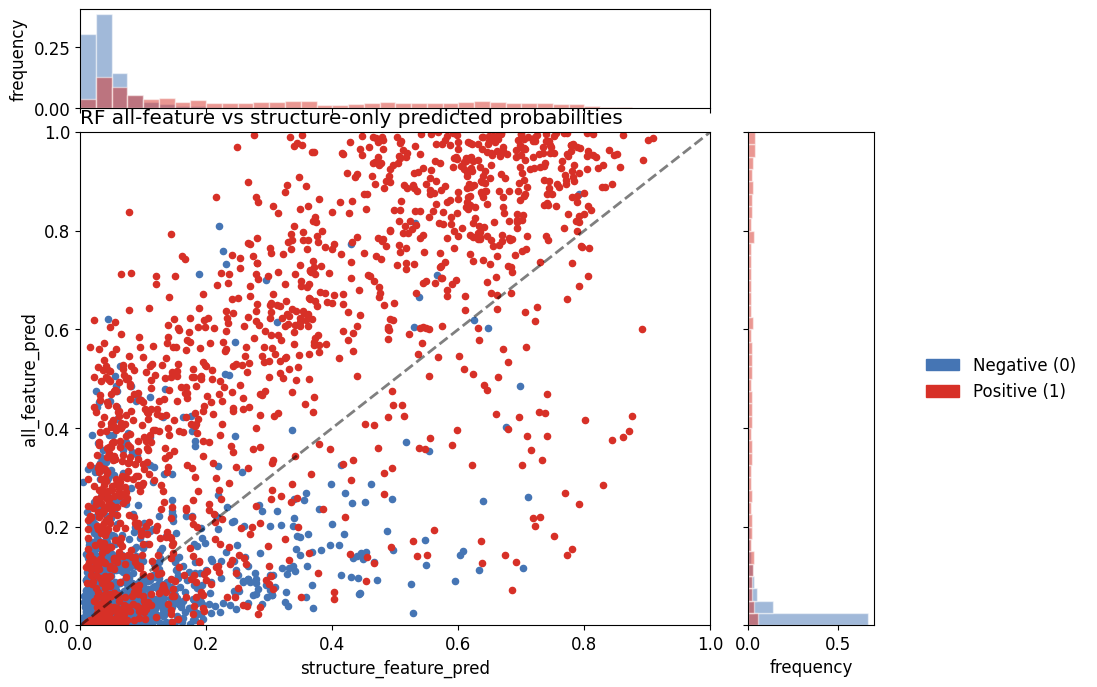

In [13]:
df_test["all_feature_pred"] = y_prob_all
df_test["structure_feature_pred"] = y_prob_struct
df_test["label"] = df_test["label"].astype(int)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 离散颜色：0=负样本（蓝），1=正样本（红）
neg_c = '#4575B4'
pos_c = '#D73027'
pos = df_test['label'] == 1
neg = ~pos
bins = np.linspace(0, 1, 41)   # 分桶

x_neg = df_test.loc[neg, 'structure_feature_pred']
x_pos = df_test.loc[pos, 'structure_feature_pred']
y_neg = df_test.loc[neg, 'all_feature_pred']
y_pos = df_test.loc[pos, 'all_feature_pred']

# 布局：主图 + 顶部 x 直方图 + 右侧 y 直方图 + 最右侧图例区
fig = plt.figure(figsize=(13, 8), facecolor='white')
gs = fig.add_gridspec(2, 3, width_ratios=(5, 1, 1.4), height_ratios=(1, 5),
                      wspace=0.12, hspace=0.08)

ax_x = fig.add_subplot(gs[0, 0])            # 顶部：x 边际直方图
ax_main = fig.add_subplot(gs[1, 0], sharex=ax_x)   # 主散点
ax_y = fig.add_subplot(gs[1, 1], sharey=ax_main)   # 右侧：y 边际直方图
ax_leg = fig.add_subplot(gs[1, 2])          # 图例专用区
ax_leg.axis('off')

# ── 主散点 ──
ax_main.scatter(df_test.loc[neg, 'structure_feature_pred'], df_test.loc[neg, 'all_feature_pred'],
                c=neg_c, s=20)
ax_main.scatter(df_test.loc[pos, 'structure_feature_pred'], df_test.loc[pos, 'all_feature_pred'],
                c=pos_c, s=20)
ax_main.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_main.set_xlabel('structure_feature_pred')
ax_main.set_ylabel('all_feature_pred')
ax_main.set_title('RF all-feature vs structure-only predicted probabilities', loc='left')
ax_main.set_xlim(0, 1)
ax_main.set_ylim(0, 1)

# ── 顶部：x 方向直方图（每个 bin 的样本占比，正负分别归一化）──
ax_x.hist(x_neg, bins=bins, color=neg_c, alpha=0.5,
          weights=np.ones_like(x_neg) / len(x_neg))
ax_x.hist(x_pos, bins=bins, color=pos_c, alpha=0.5,
          weights=np.ones_like(x_pos) / len(x_pos))
ax_x.tick_params(labelbottom=False)
ax_x.set_ylabel('frequency')

# ── 右侧：y 方向直方图（每个 bin 的样本占比，正负分别归一化，水平）──
ax_y.hist(y_neg, bins=bins, color=neg_c, alpha=0.5,
          weights=np.ones_like(y_neg) / len(y_neg), orientation='horizontal')
ax_y.hist(y_pos, bins=bins, color=pos_c, alpha=0.5,
          weights=np.ones_like(y_pos) / len(y_pos), orientation='horizontal')
ax_y.tick_params(labelleft=False)
ax_y.set_xlabel('frequency')

# ── 图例（最右侧专用区，居中）──
ax_leg.legend(
    handles=[Patch(color=neg_c, label='Negative (0)'),
             Patch(color=pos_c, label='Positive (1)')],
    loc='center left', frameon=False, fontsize=12)
fig.savefig(f'{FIG_DIR}/fig_rf_all_vs_struct_scatter.pdf', bbox_inches='tight')
# fig.savefig(f'{FIG_DIR}/fig_rf_all_vs_struct_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

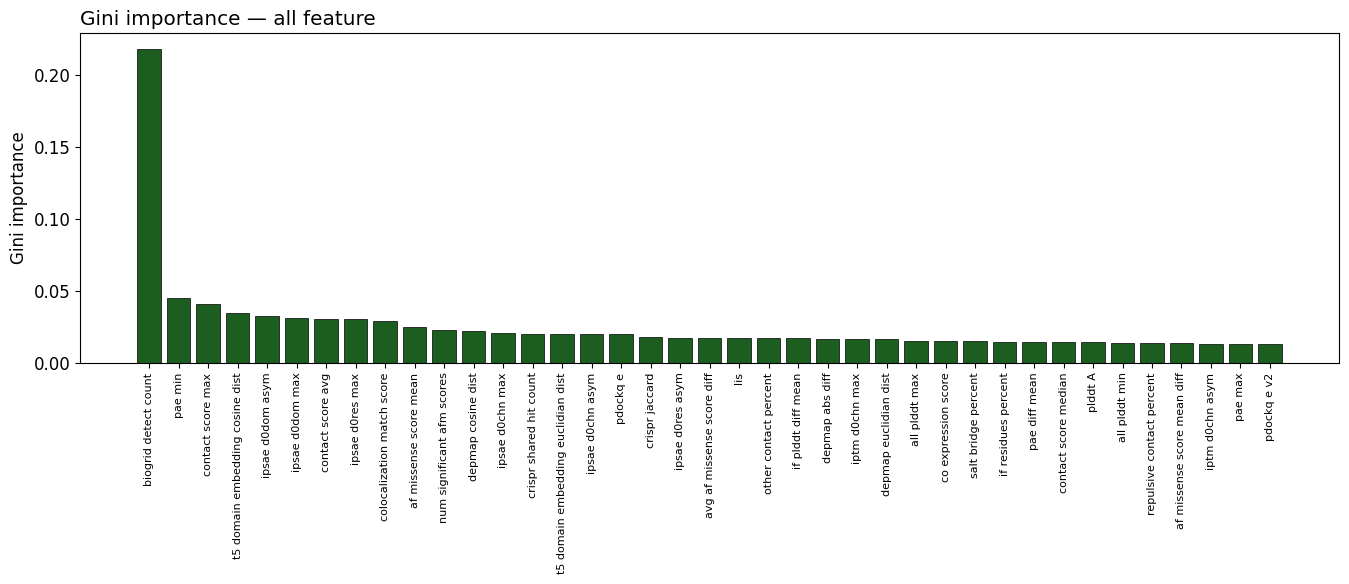

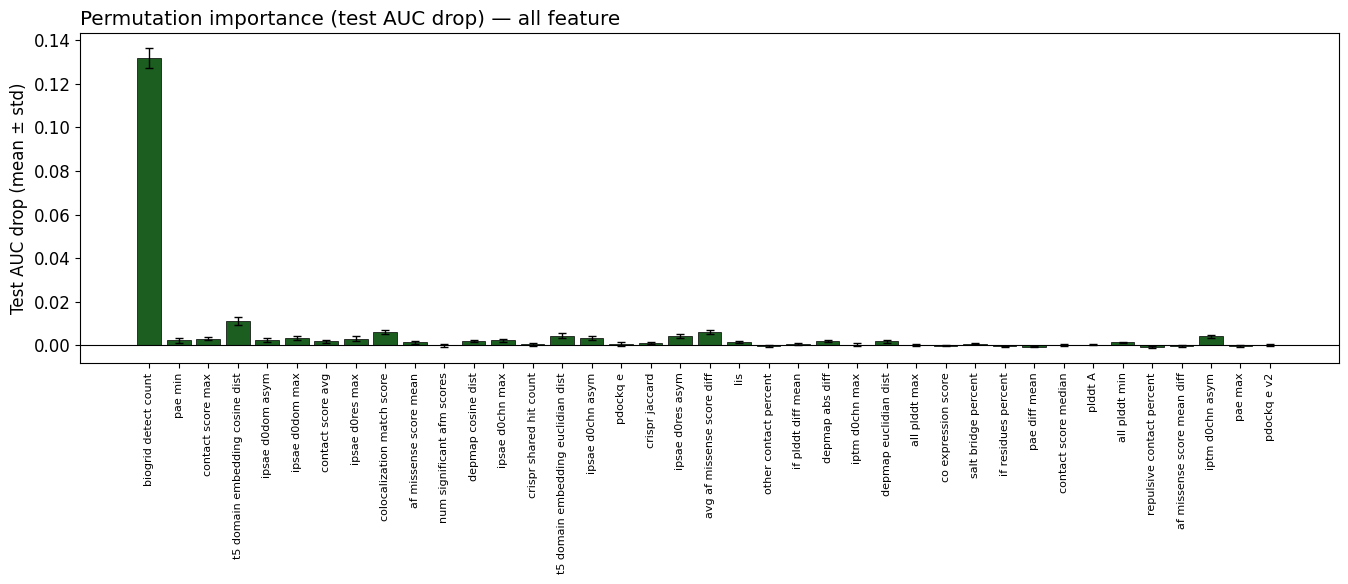

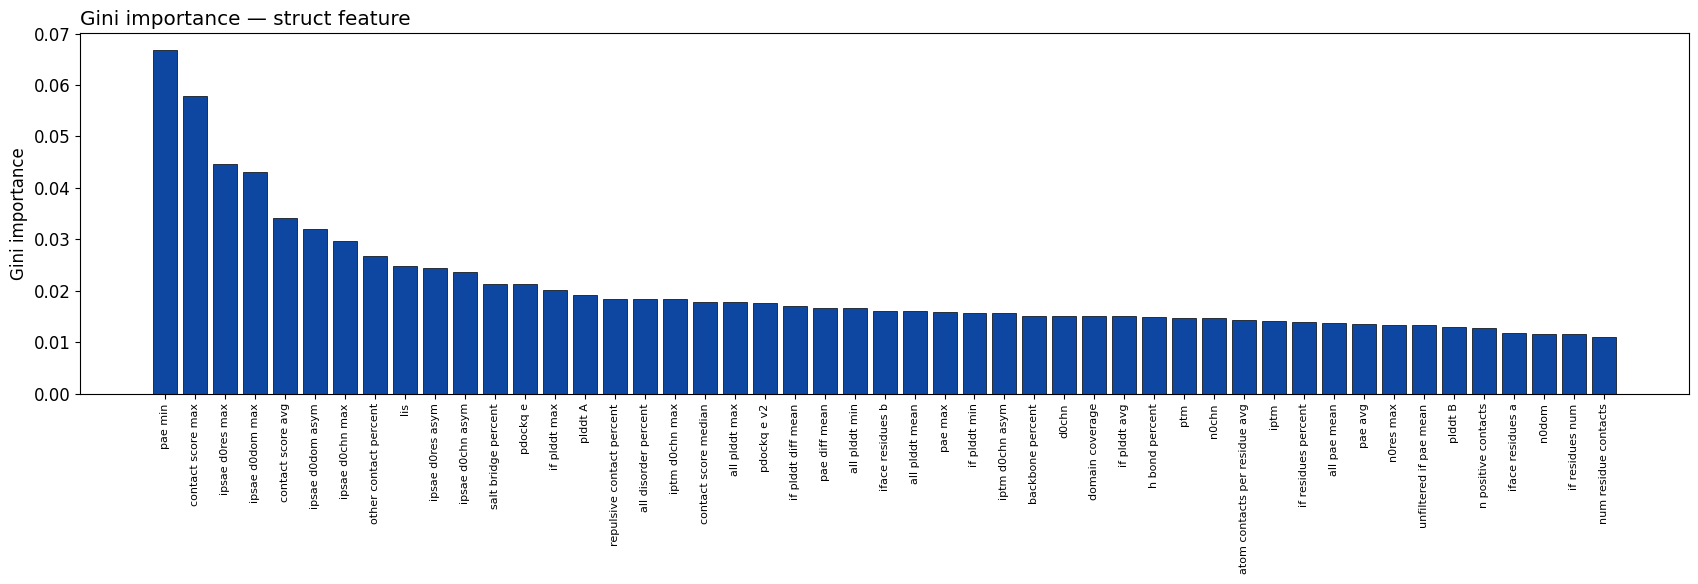

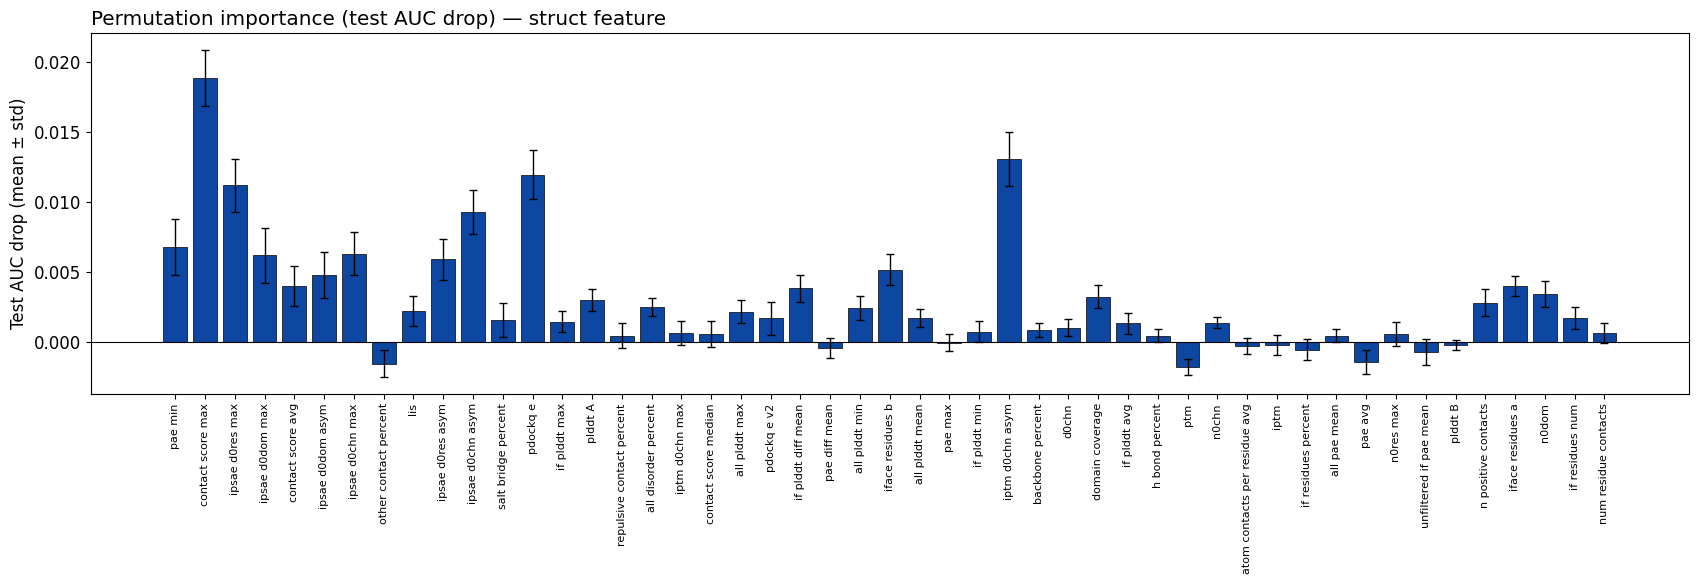

Done: 4 figures saved to /home/data/xjd/ESMFOLD_filter/FP_classifier/figures


In [14]:
# ══════════════════════════════════════════════════════════
# Permutation importance — Gini vs Test AUC Drop (mean ± std)
# 4 figures: {all_feature, struct_feature} × {gini, auc_drop}
# 数据源: rf_permutation_importance_allfeat.csv / structfeat.csv
# ══════════════════════════════════════════════════════════
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = globals().get('BASE', os.path.join(REPO, 'data', 'analysis'))
FIG_DIR = os.path.join(REPO, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

MODEL_CSVS = [
    ('all_feature',    f'{BASE}/dataset/rf_permutation_importance_allfeat.csv',    '#1B5E20'),
    ('struct_feature', f'{BASE}/dataset/rf_permutation_importance_structfeat.csv', '#0D47A1'),
]

for tag, csv_path, color in MODEL_CSVS:
    tag_label = tag.replace('_', ' ')    # 图内文字用: all feature / struct feature
    df = pd.read_csv(csv_path).sort_values('test_aupr_drop_mean', ascending=False).reset_index(drop=True)
    df = df.sort_values('gini_importance', ascending=False).reset_index(drop=True)
    feats = [f.replace('_', ' ') for f in df['feature'].tolist()]   # x 轴特征名: _ → 空格
    x = np.arange(len(feats))
    fig_w = max(10, 0.35 * len(feats))   # 特征多时加宽，避免刻度挤在一起

    # ── 图1: Gini importance ──
    fig, ax = plt.subplots(figsize=(fig_w, 6), facecolor='white')
    ax.bar(x, df['gini_importance'], color=color, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=90, fontsize=8)
    ax.set_ylabel('Gini importance')
    ax.set_title(f'Gini importance — {tag_label}', loc='left')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/fig_perm_gini_{tag}.pdf', bbox_inches='tight')
    plt.show()

    # ── 图2: test AUC drop (mean ± std error bars) ──
    fig, ax = plt.subplots(figsize=(fig_w, 6), facecolor='white')
    ax.bar(x, df['test_auc_drop_mean'],
           yerr=df['test_auc_drop_std'],
           color=color, edgecolor='black', linewidth=0.5,
           capsize=3, error_kw={'elinewidth': 1.0, 'ecolor': 'black'})
    ax.axhline(0, color='black', linewidth=0.8)   # 0 参考线，负值特征在下方
    ax.set_xticks(x)
    ax.set_xticklabels(feats, rotation=90, fontsize=8)
    ax.set_ylabel('Test AUC drop (mean ± std)')
    ax.set_title(f'Permutation importance (test AUC drop) — {tag_label}', loc='left')
    fig.tight_layout()
    fig.savefig(f'{FIG_DIR}/fig_perm_aucdrop_{tag}.pdf', bbox_inches='tight')
    plt.show()

print(f'Done: 4 figures saved to {FIG_DIR}')

In [15]:
# ══════════════════════════════════════════════════════════
# 结构可视化 (py3Dmol) + PAE/pLDDT 图（独立 cell，可单独运行）
# 输入 dimer_id，读取 CIF/NPZ 展示 3D 结构 + PAE + pLDDT
# ══════════════════════════════════════════════════════════
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import py3Dmol
from scipy.stats import pearsonr

# ==================== 改这里 ====================
DIMER_ID = "IQSEC1;Q6DN90;1_ARF6"
CIF_DIR = os.path.join(BASE, 'example', 'ARF6_0')
# ================================================

cif_path = os.path.join(CIF_DIR, f"{DIMER_ID}.cif")
npz_path = os.path.join(CIF_DIR, f"{DIMER_ID}.npz")

assert os.path.exists(cif_path), f"CIF not found: {cif_path}"
assert os.path.exists(npz_path), f"NPZ not found: {npz_path}"

# ── 加载 ──
with open(cif_path) as f:
    cif_str = f.read()

data = np.load(npz_path, allow_pickle=False)
pae = data['pae']
plddt = data['plddt']

# 两链长度（用于 PAE 边界线；ARF6_0 的 NPZ 无 input_asym_id，从 CIF 解析）
sys.path.insert(0, os.path.join(REPO, 'modules'))
from structure_feature_export import read_cif
cif_struct = read_cif(cif_path)
chains = list(cif_struct.keys())
a_len = int((cif_struct[chains[0]]['names'] == 'CA').sum())
n_res = len(plddt)
b_len = n_res - a_len

print(f"Dimer: {DIMER_ID}")
print(f"  Chain A: {a_len}, Chain B: {b_len}, Total: {n_res}")
print(f"  pLDDT mean: {plddt.mean():.3f}   ipTM: {float(data['iptm']):.4f}")

# ── PAE + pLDDT（1×2 子图）──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(pae, cmap='Greens_r', vmin=0, vmax=30, aspect='auto')
axes[0].axhline(y=a_len - 0.5, color='black', linewidth=1)
axes[0].axvline(x=a_len - 0.5, color='black', linewidth=1)
axes[0].set_title(f'PAE — {DIMER_ID}  (iptm={float(data["iptm"]):.3f})')
axes[0].set_xlabel('Residue (scored)')
axes[0].set_ylabel('Residue (aligned)')
plt.colorbar(im, ax=axes[0], label='PAE (Å)')

# pLDDT：残基多时 bar 太细（默认黑描边会盖住颜色），用 step 线 + 填色更清晰
x = np.arange(n_res)
axes[1].fill_between(x, plddt, step='mid', alpha=0.35, color='#2196F3')
axes[1].plot(x, plddt, color='#333333', lw=0.8)
axes[1].axvline(x=a_len - 0.5, color='black', linewidth=1, ls='--')
axes[1].set_ylim(0, 1)
axes[1].set_title('pLDDT per Residue')
axes[1].set_xlabel('Residue index')
axes[1].set_ylabel('pLDDT')

plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_pae_plddt_structure.pdf', bbox_inches='tight')
fig.savefig(f'{FIG_DIR}/fig_pae_plddt_structure.png', dpi=300, bbox_inches='tight')
plt.show()

# ── 3D 结构 (py3Dmol) ──
view = py3Dmol.view(width=800, height=500)
view.addModel(cif_str, 'cif')
view.setStyle({'chain': 'A'}, {'cartoon': {'color': '#2196F3', 'opacity': 0.8}})
view.setStyle({'chain': 'B'}, {'cartoon': {'color': '#FF5722', 'opacity': 0.8}})
view.zoomTo()
view.show()


# ══════════════════════════════════════════════════════════
# RF score vs ipTM / ipSAE 相关性散点图（n_positive_contacts >= 5）
# ══════════════════════════════════════════════════════════
BASE_DIR = os.path.join(BASE, 'example', 'ARF6_0')

# 加载并合并
rf = pd.read_csv(f'{BASE_DIR}/ARF6_0.tsv', sep='\t')
sm = pd.read_csv(f'{BASE_DIR}/ARF6_0_summary.tsv', sep='\t')

rf['model_idx'] = rf['fname'].str.extract(r';(\d+)_ARF6$').astype(int)
dfm = rf.merge(
    sm[['gene', 'uniprot_id', 'segment', 'ipTM', 'ipSAE']],
    left_on=['gene', 'uniprot_A', 'model_idx'],
    right_on=['gene', 'uniprot_id', 'segment'], how='left')

# 过滤器：只保留 n positive contacts >= 5
dfm = dfm[dfm['n_c+'] >= 5].copy()
print(f"\n[散点] C+ >= 5 子集: {len(dfm)} 对")

# 4 张散点图：RF all_feat / struct_only  vs  ipTM / ipSAE
pairs = [
    ('score_all_feat',    'ipTM',  'RF all-feat score', 'ipTM'),
    ('score_all_feat',    'ipSAE', 'RF all-feat score', 'ipSAE'),
    ('score_struct_only', 'ipTM',  'RF struct-only score', 'ipTM'),
    ('score_struct_only', 'ipSAE', 'RF struct-only score', 'ipSAE'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
for ax, (cx, cy, lx, ly) in zip(axes.flatten(), pairs):
    sub = dfm[[cx, cy]].apply(pd.to_numeric, errors='coerce').dropna()
    r, p = pearsonr(sub[cx], sub[cy])
    ax.scatter(sub[cx], sub[cy], s=10, alpha=0.35, color='#2196F3')
    # 线性拟合线
    m, b = np.polyfit(sub[cx], sub[cy], 1)
    xs = np.linspace(sub[cx].min(), sub[cx].max(), 100)
    ax.plot(xs, m * xs + b, color='#FF5722', lw=1.5, ls='--')
    ax.set_xlabel(lx)
    ax.set_ylabel(ly)
    ax.set_title(f'{lx} vs {ly}\nPearson r = {r:.4f}  (n={len(sub)})')

plt.suptitle('RF Score vs ipTM/ipSAE (ARF6_0, C+>=5)', fontsize=15)
plt.tight_layout()
fig.savefig(f'{FIG_DIR}/fig_rf_score_vs_iptm_ipsae.pdf', bbox_inches='tight')
# fig.savefig(f'{FIG_DIR}/fig_rf_score_vs_iptm_ipsae.png', dpi=300, bbox_inches='tight')
plt.show()

AssertionError: CIF not found: /home/data/xjd/ESMFOLD_filter/FP_classifier/example/ARF6_0/IQSEC1;Q6DN90;1_ARF6.cif